In [3]:
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# train_df   = pd.read_csv(file_loc + 'train_df.csv')
# holdout_df = pd.read_csv(file_loc + 'holdout_df.csv')
# drop all long_profit / short_profit variables
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq
file_loc = '/mnt/disks/filedisk2a/Qingcheng/'

SPP_family_dt_features = download_df_from_bq(
    "SELECT * FROM `movetocloud-999.qctest.SPP_family_dt_features`"
)
print(SPP_family_dt_features.shape)
SPP_family_dt_features.head()

SPP_family_dt_features = SPP_family_dt_features.query('dt >= "2021-06-01" and dt< "2026-06-01"')

# break in to holdout period and non-holdout period 
# holdout
holdout_mon_lst = [
    '2021-06', '2021-09', '2021-12', 
    '2022-08',  '2022-11' ,'2022-02', 
    '2023-10', '2023-01', '2023-04',
    '2024-03', '2024-07', '2024-12', 
    '2025-05', '2025-09', '2025-01',
    '2026-03', '2026-05']

mon = pd.to_datetime(SPP_family_dt_features['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = SPP_family_dt_features[is_holdout].copy()     # dt in the listed months
train_df   = SPP_family_dt_features[~is_holdout].copy()    # dt not in those months

print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")
# sanity: every listed month actually present?
missing = set(holdout_mon_lst) - set(mon.unique())
print("listed months with no rows:", sorted(missing))

# go_nogo_df
go_nogo_df = pd.read_csv('/mnt/disks/filedisk2a/Jessica/tmp/' + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
print(go_nogo_df['nogo'].unique())

tier1_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 1, 'dt'].values)
tier2_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 2, 'dt'].values)

print(tier1_dt)
nogo_dt = tier1_dt | tier2_dt                      # all no-go days (nogo == 1 or 2)
clean = SPP_family_dt_features[~SPP_family_dt_features['dt'].isin(nogo_dt)].copy()   # keep go-days only

mon = pd.to_datetime(clean['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = clean[is_holdout].copy()    # listed months, no-go removed
train_df   = clean[~is_holdout].copy()   # other months, no-go removed

print("dropped no-go days:", SPP_family_dt_features['dt'].isin(nogo_dt).sum(), "rows")
print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")


(2037917, 106)
holdout: 519 days | 566418 rows
train  : 1307 days | 1461771 rows
listed months with no rows: []
[0 2 1]
{'2023-08-21', '2024-07-30', '2022-08-02', '2024-07-31', '2024-07-15', '2021-02-13', '2021-02-15', '2025-01-20', '2024-01-16', '2023-07-26', '2026-01-25', '2025-02-18', '2025-02-19', '2023-08-22', '2021-02-12', '2026-01-27', '2024-01-20', '2022-12-22', '2023-08-24', '2022-12-23', '2022-07-15', '2026-01-24', '2021-02-17', '2022-12-24', '2024-01-13', '2023-07-27', '2021-02-18', '2026-01-28', '2021-02-14', '2023-08-23', '2022-07-19', '2024-01-14', '2025-02-20', '2024-01-15', '2021-02-16', '2022-02-23', '2026-01-26', '2023-08-19'}
dropped no-go days: 72236 rows
holdout: 495 days | 550022 rows
train  : 1228 days | 1405931 rows


In [4]:
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
from nighthawk.data.network.constraint_family import ConstraintFamily

def replace_monitored_name(df, fam_col='constraint_family_num'):
    fams = pd.Series(df[fam_col].dropna().unique()).astype('int64')
    cf = ConstraintFamily('SPP', constraint_family_num_df=pd.DataFrame({'constraintFamilyNum': fams}))
    name_map = (cf.get_constraint_family_details()[['constraintFamilyNum', 'constraintName']]
                  .drop_duplicates('constraintFamilyNum')
                  .rename(columns={'constraintFamilyNum': fam_col, 'constraintName': 'monitored_name'}))
    print('families mapped:', name_map[fam_col].nunique(), '/', df[fam_col].nunique())
    df = df.copy()
    df[fam_col] = df[fam_col].astype('int64')
    return df.drop(columns=['monitored_name'], errors='ignore').merge(name_map, on=fam_col, how='left')

train_df = replace_monitored_name(train_df)
holdout_df = replace_monitored_name(holdout_df)
train_df[['constraint_family_num', 'monitored_name']].drop_duplicates().head()

families mapped: 1477 / 1722
families mapped: 1244 / 1489


,constraint_family_num,monitored_name
0,590346,xfmrforman-forman
8,704807,lnn345-blackbry
41,1062,xfmrstilwell-stilwell
63,535,lnnash_mps-lbrtywt5
64,54,lnaur1241-rdspg5


In [5]:
import numpy as np, pandas as pd

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['short_profit']) & (train_df['short_profit'] < 0)

probs = [0.0, *QS, 1.0]
edges = np.unique(train_df.loc[neg, 'short_profit'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['short_profit_q'] = pd.cut(
    train_df['short_profit'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['short_profit_q'].value_counts(dropna=False).sort_index())


QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['rt_da']) & (train_df['rt_da'] < 0)

probs  = [0.0, *QS, 1.0]
edges  = np.unique(train_df.loc[neg, 'rt_da'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['rt_da_q'] = pd.cut(
    train_df['rt_da'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['rt_da_q'].value_counts(dropna=False).sort_index())
# keep only rows with a band on BOTH sides, then make each short_profit column sum to 100%
sub = train_df.dropna(subset=['rt_da_q', 'short_profit_q'])
ct  = pd.crosstab(sub['rt_da_q'], sub['short_profit_q'])
print((ct.div(ct.sum(0), axis=1) * 100).round(1))   # column %: each short_profit band sums to 100

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['short_profit'] < 0
print(train_df.loc[neg, 'short_profit'].quantile([0, *QS, 1]).round(1))

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['rt_da'] < 0
print(train_df.loc[neg, 'rt_da'].quantile([0, *QS, 1]).round(3))




short_profit_q
p0-p1           190
p1-p5           756
p5-p10          946
p10-p30        3782
p30-p50        3783
p50-p70        3782
p70-p90        3782
p90-p95         946
p95-p99         756
p99-p100        190
NaN         1387018
Name: count, dtype: int64
rt_da_q
p0-p1           243
p1-p5           968
p5-p10         1211
p10-p30        4844
p30-p50        4843
p50-p70        4843
p70-p90        4844
p90-p95        1211
p95-p99         968
p99-p100        243
NaN         1381713
Name: count, dtype: int64
short_profit_q  p0-p1  p1-p5  p5-p10  p10-p30  p30-p50  p50-p70  p70-p90  \
rt_da_q                                                                    
p0-p1            20.5    7.7     3.8      1.0      0.5      0.3      0.1   
p1-p5            40.0   24.8    16.3      5.9      2.1      1.1      0.5   
p5-p10           18.9   21.4    17.5      8.9      4.0      1.9      1.1   
p10-p30          19.5   33.3    41.4     38.6     23.3     12.6      7.0   
p30-p50           0.5   10.8 

# rt - da quantile: p0-p10 -33641 - -2712 would emcompass ~90% top 1% congestion loss days,  ~60% top 1%-5% loss days.

In [6]:
# new feature that rt-da smaller than -3000 as 1 and not -3000 as 0, we want to test split that would best predict 1 
for df in (train_df, holdout_df):
    df['bad_rtda'] = (df['rtm'] - df['dam'] < -3000).astype(int)
    
print('train_df :', train_df['bad_rtda'].value_counts().to_dict())
print('holdout_df:', holdout_df['bad_rtda'].value_counts().to_dict())

train_df : {0: 1403677, 1: 2254}
holdout_df: {0: 549083, 1: 939}


# merge with physical variables and the dfax related variables 

In [7]:
# merge daily physical variables (wind / load / genoutage / ice price / gas price forecast) onto the splits
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd, numpy as np
from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.data.pipeline.var_handler import ice_elec_price_vh
from nighthawk.util import sql_functions          # for the gas query

OPEX = 'SPP'

dts = pd.concat([train_df['dt'], holdout_df['dt']]).astype(str)
start_dt, end_dt = dts.min(), dts.max()
print('phys date range:', start_dt, '->', end_dt)

def _daily(df, col, name):
    """hourly forecast -> daily mean, dt as 'YYYY-MM-DD' string"""
    df = df.copy()
    df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d')
    return df.groupby('dt', as_index=False)[col].mean().rename(columns={col: name})

# --- wind / load / genoutage daily forecast ---
wind_df  = wind.Wind(OPEX).get_total_wind(start_dt, end_dt, var_spec=['f'], impute=True)
wind_daily = _daily(wind_df, 'spp_wind_total_forecast_f', 'wind_forecast')

load_df  = load.Load(OPEX).get_total_load(start_dt, end_dt, var_spec=['f'], impute=True)
load_daily = _daily(load_df, 'spp_load_total_forecast_f', 'load_forecast')

go_df    = genoutage.GenOutage(OPEX).get_genoutage_by_level(start_dt, end_dt, var_spec=['f'], area_list=['SPP'])
go_col   = [c for c in go_df.columns if c.endswith('_forecast_f')][0]
genoutage_daily = _daily(go_df, go_col, 'genoutage_forecast')

# --- ice electricity price forecast (INDIANAHUB proxy for SPP, node 636) ---
ice_df, _ = ice_elec_price_vh.get_data_and_mapping_for_ice_elec(
    [636], OPEX, ['INDIANAHUB'], start_dt, end_dt, var_spec=['f'], impute=True)
ice_daily = _daily(ice_df, 'INDIANAHUB_ice_elec_price_forecast_f', 'ice_price_forecast')

# --- gas price forecast: max(henry, panhandle), same source the SPP investment cut uses ---
gas_df = sql_functions.download_df_from_sql_db(f"""
    SELECT dt, henryHub AS henry, panHandleHub AS panhandle
    FROM odessa_VirtualStrategy_MISO.iceVariables
    WHERE dt BETWEEN '{start_dt}' AND '{end_dt}'
""")
gas_df['dt'] = pd.to_datetime(gas_df['dt']).dt.strftime('%Y-%m-%d')
gas_df[['henry', 'panhandle']] = gas_df[['henry', 'panhandle']].replace(0, np.nan)  # 0 == missing
gas_df['gas_price_forecast'] = gas_df[['henry', 'panhandle']].max(axis=1)           # SPP uses max of the two hubs
gas_daily = gas_df.groupby('dt', as_index=False)['gas_price_forecast'].mean()

# --- combine all daily physical variables (gas last) ---
phys_daily = (wind_daily
              .merge(load_daily,      on='dt', how='outer')
              .merge(genoutage_daily, on='dt', how='outer')
              .merge(ice_daily,       on='dt', how='outer')
              .merge(gas_daily,       on='dt', how='outer'))
print('phys_daily:', phys_daily.shape)
display(phys_daily.head())

# --- merge onto train / holdout (dt-level) ---
train_df['dt']   = train_df['dt'].astype(str)
holdout_df['dt'] = holdout_df['dt'].astype(str)
train_df   = train_df.merge(phys_daily, on='dt', how='left')
holdout_df = holdout_df.merge(phys_daily, on='dt', how='left')
print('train_df  :', train_df.shape, '| holdout_df:', holdout_df.shape)
train_df.head()


phys date range: 2021-06-01 -> 2026-05-31
phys_daily: (1826, 6)


,dt,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,2021-06-01,3035.128750,25932.625000,11504.891667,24.873333,2.89
1,2021-06-02,1916.375000,26712.708333,11762.216667,26.790000,2.95
2,2021-06-03,3768.707917,28603.416667,11286.708333,28.130000,3.04
3,2021-06-04,9523.051667,30291.458333,11359.608333,29.570000,3.03
4,2021-06-05,13756.800417,29792.250000,11398.025000,29.783333,2.99


train_df  : (1405931, 114) | holdout_df: (550022, 112)


,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,...,KV_group,monitored_name,short_profit_q,rt_da_q,bad_rtda,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,2023-05-26,590346,11274.76567,10692.34277,33.485800,0.727139,28.52727,0.00000,NaN,NaN,...,04_345,xfmrforman-forman,NaN,NaN,0,12855.018333,30131.083333,16764.841667,26.733333,2.23
1,2024-02-10,590346,14659.04490,15662.68927,554.974400,63.467606,0.79344,62.35952,1.008927,0.000000,...,04_345,xfmrforman-forman,NaN,p70-p90,0,11192.910000,29517.000000,7895.741667,18.560000,1.66
2,2024-04-20,590346,38097.74868,41034.39107,370.400605,185.089187,181.27872,0.00000,45196.606159,0.000000,...,04_345,xfmrforman-forman,NaN,p1-p5,1,13297.224583,27499.458333,29262.058333,23.503333,1.45
3,2023-03-18,590346,9630.73892,9572.18868,238.307680,62.361310,2.69760,34.06464,-276.193992,7915.174143,...,04_345,xfmrforman-forman,NaN,p10-p30,0,14024.211250,31742.791667,17521.708333,27.393333,2.40
4,2023-03-25,590346,1363.50882,677.41110,50.607358,451.229103,8.65512,19.39028,-886.143942,440.429382,...,04_345,xfmrforman-forman,NaN,NaN,0,9163.325833,27732.125000,20746.666667,22.876667,2.04


In [8]:
# load (drop the unnamed index col) and align the key name
dfax = (pd.read_csv(file_loc + 'dfax_variable.csv', index_col=0)
          .rename(columns={'constraintFamilyNum': 'constraint_family_num'}))
dfax['dt'] = dfax['dt'].astype(str)
dfax['constraint_family_num'] = dfax['constraint_family_num'].astype('int64')

# dfax should be unique per (dt, family) so the left join can't duplicate rows
assert not dfax.duplicated(['dt', 'constraint_family_num']).any(), 'dfax has dup (dt,family) keys'

# align the key dtypes on both frames, then left-join
for df in (train_df, holdout_df):
    df['dt'] = df['dt'].astype(str)
    df['constraint_family_num'] = df['constraint_family_num'].astype('int64')

train_df   = train_df.merge(dfax,   on=['dt', 'constraint_family_num'], how='left')
holdout_df = holdout_df.merge(dfax, on=['dt', 'constraint_family_num'], how='left')

print('train_df  :', train_df.shape,   '| dfax matched:', f"{train_df['dfax_max'].notna().mean()*100:.1f}%")
print('holdout_df:', holdout_df.shape, '| dfax matched:', f"{holdout_df['dfax_max'].notna().mean()*100:.1f}%")

train_df  : (1405931, 125) | dfax matched: 99.9%
holdout_df: (550022, 123) | dfax matched: 99.8%


In [9]:
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util import bigquery_functions as bq

dam = bq.download_df_from_bq("SELECT * FROM `movetocloud-999.qctest.SPP_dam_hr_max`")

# align the family-key name to whatever train_df uses, and dt to string
fk = 'constraint_family_num' if 'constraint_family_num' in train_df.columns else 'constraintFamilyNum'
dam = dam.rename(columns={'constraintFamilyNum': fk})
dam['dt'] = pd.to_datetime(dam['dt']).dt.strftime('%Y-%m-%d')  
dam[fk]   = dam[fk].astype(float)
cols = [fk, 'dt', 'dam_hr_max_lag2', 'dam_hr_max_7d', 'dam_hr_max_1m', 'dam_hr_max_3m']
dam = dam[cols]

feat = ['dam_hr_max_lag2','dam_hr_max_7d','dam_hr_max_1m','dam_hr_max_3m']
def attach(df):
    df = df.drop(columns=[c for c in feat if c in df.columns])   # idempotent: avoid _x/_y
    df['dt'] = df['dt'].astype(str); df[fk] = df[fk].astype(float)
    return df.merge(dam, on=[fk,'dt'], how='left')

train_df   = attach(train_df)
holdout_df = attach(holdout_df)

print("train match rate  :", train_df['dam_hr_max_lag2'].notna().mean().round(3))
print("holdout match rate:", holdout_df['dam_hr_max_lag2'].notna().mean().round(3))


train match rate  : 0.809
holdout match rate: 0.81


# Step 1: Shrink the dataset to model to have the constraints that has mvalue smaller than rt or da mvalue smaller than -500 



In [8]:
train_df['rt_da_smaller_500'] = ((train_df['rtm'] < -500) | (train_df['dam'] < -500)).astype(int)

In [9]:
# === 1. feature setup (family-day level) ===
KEYS    = ['dt', 'constraint_family_num']
TARGETS = ['rt_da_smaller_500']
# same-day realized / id columns -> EXCLUDE (leakage or non-features)
LEAK = ['dam', 'rtm', 'da_mvalue', 'rt_mvalue', 'bad_short', 'rt_da', 'rt_binds',
        'oops_constraint_num', 'monitored_clean', 'contingency_clean',
        'monitored_name', 'node_name',
       'short_profit_q', 'rt_da_q', 'bad_rtda','long_profit','short_profit','profit_congestion','profit','short_bid_mw','long_bid_mw']

num_cols = train_df.select_dtypes('number').columns.tolist()
features = [c for c in num_cols if c not in KEYS + TARGETS + LEAK]
CATS     = [c for c in ['KV_group'] if c in train_df.columns]   # categorical driver(s)

# tag features so you can separate "it was bad recently" from real conditions
persistence = [c for c in features if 'profit_sum' in c]
condition   = [c for c in features if c not in persistence]

print(f"{len(features)} numeric features (+{len(CATS)} categorical: {CATS})")
print(f"\nPERSISTENCE ({len(persistence)}): {persistence}")
print(f"\nCONDITION   ({len(condition)}): {condition}")

108 numeric features (+1 categorical: ['KV_group'])

PERSISTENCE (0): []

CONDITION   (108): ['long_clear_mw', 'short_clear_mw', 'FlowRatio', 'ShadowPrice_min', 'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d', 'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y', 'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d', 'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m', 'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m', 'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y', 'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y', 'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m', 'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m', 'rt_max_3m', 'rt_max_1y', 'rt_max_3y', 'rt_nz_cnt_7d', 'rt_nz_cnt_1m', 'rt_nz_cnt_3m', 'rt_nz_cnt_1y', 'rt_nz_cnt_3y', 'rt_spike_7d', 'rt_spike_1m', 'rt_spike_3m', 'rt_spike_1y', 'rt_spike_3y', 'rtm_hr_max_lag2', 'rtm_peak_shar

Given the tree result, rtm_sum_1m<0 and many correlated ones give similar results that this would give the most coverage. 

## Driver analysis — what moves long & short profit (family-day level)

Goal: rank the variables that drive **rt-da < 3000** and **profit_congestion**, both as a
*level* (regression) and as *tail-loss events* using the pinball loss, then translate the top
stable drivers into cut rules. Importance is judged on the **holdout** split (out-of-sample) and
cross-checked by SHAP **and** permutation importance — only drivers that agree are trusted.

**Leakage guard:** same-day realized `dam`/`rtm` are excluded (they are contemporaneous with the
loss). Only lagged/rolling history and pre-bid forecasts (FlowRatio, wind/load/genoutage/gas) are used.

**result** show the feature importance, recall rate at holding set and the best split points at top 


In [10]:
train_df_filter = train_df.query('rtm_sum_1m<-200 or dam_sum_1m<-500')

# Remove variables with strong correlation over .8 

In [11]:
import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

CORR_CUT    = 0.80          # |Spearman| >= this -> same cluster (keep one representative)
TAIL_TARGET = 'bad_rtda'    # rep = member most correlated with this; set to TARGETS[0] to match your model target

pool = [c for c in train_df_filter.select_dtypes('number').columns
        if c not in set(KEYS + TARGETS + LEAK)]
assert len(pool) >= 2, 'need >= 2 numeric features to cluster'

# 1) |Spearman| correlation -> symmetric distance (1 - |rho|)
corr = train_df_filter[pool].corr('spearman').abs().fillna(0.0)
dist = 1.0 - corr.values
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2                       # enforce exact symmetry for squareform

# 2) average-linkage clustering; cut so members with |rho| >= CORR_CUT group together
cl = pd.Series(
    fcluster(linkage(squareform(dist, checks=False), method='average'),
             t=1 - CORR_CUT, criterion='distance'),
    index=pool)

# 3) representative per cluster = member most correlated with TAIL_TARGET
tcorr = train_df_filter[pool].apply(
    lambda s: abs(s.corr(train_df_filter[TAIL_TARGET], method='spearman'))).fillna(0.0)

compact, cluster_map, dropped = [], {}, {}
for c in sorted(cl.unique()):
    mem = cl[cl == c].index.tolist()
    rep = tcorr[mem].idxmax()
    compact.append(rep)
    for m in mem:
        cluster_map[m] = rep                     # every feature -> its kept representative
    if len(mem) > 1:
        dropped[rep] = [m for m in mem if m != rep]
        print(f'[{rep}]  <- {dropped[rep]}')

compact = sorted(compact)
print(f'\ncompact = {len(compact)} of {len(pool)} features  (dropped {len(pool) - len(compact)} collinear)')


NameError: name 'KEYS' is not defined

In [ ]:
# columns to keep alongside the decorrelated features
keep_extra = ['dt', 'constraint_family_num',          # keys
              'KV_group',                             # categorical driver (not in numeric compact)
              'bad_rtda', 'rt_da', 'rt_da_q', 'rt_da_smaller_500',   # targets / labels
              'short_profit', 'long_profit', 'profit_congestion',    # P&L for analysis
              'monitored_name']                        # id
keep = compact + [c for c in keep_extra if c in train_df_filter.columns and c not in compact]

train_df_filter = train_df_filter[keep].copy()
print(train_df_filter.shape, '| kept:', len(keep), 'cols')
print('dropped:', len(train_df_filter.columns) if False else '',  # see below
      len(set(train_df_filter.columns)))

(186578, 57) | kept: 57 cols
dropped:  57


# bad_rtda rt-da<-3000 classification 

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.dropna(subset=['bad_rtda']).copy()   # bad_rtda is 0/1
y = d['bad_rtda'].astype(int)
FEATS = globals().get('compact', features)
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                              # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); pos, N, base = int(y.sum()), len(y), y.mean()
print(f'rows={N}  y=1={pos} ({base*100:.2f}%)')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                          random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=100,
                            class_weight='balanced_subsample', random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

# ---------- 2) readable tree: split + #1s at EACH node ----------
surr = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, class_weight='balanced',
                              random_state=0).fit(Xn, y)
dp = surr.decision_path(Xn); yv = y.values.astype(bool)
n1 = np.asarray(dp[yv].sum(0)).ravel(); n0 = np.asarray(dp[~yv].sum(0)).ravel()
t = surr.tree_
print('\n=== tree splits: n1 = #(y=1) at node, purity, recall ===')
def show(nd=0, dep=0, br=''):
    tot = n1[nd] + n0[nd]; pur = n1[nd]/tot*100 if tot else 0; rec = n1[nd]/pos*100
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  n1={int(n1[nd]):>4}  purity={pur:4.1f}%  recall={rec:4.1f}%')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by #1s captured (kept from your cell)
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'n_1':int(n1[i]),'n_rows':int(n1[i]+n0[i]),
                      'recall':round(n1[i]/pos*100,1),'purity':round(n1[i]/(n1[i]+n0[i])*100,1),
                      'rule':rules[i]} for i in leaves]).sort_values('n_1',ascending=False).reset_index(drop=True))
tab['cum_recall'] = (tab['n_1'].cumsum()/pos*100).round(1); tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by # of 1s captured ===')
for _, r in tab.iterrows():
    print(f"n_1={int(r['n_1']):>4}  recall={r['recall']:>5}%  purity={r['purity']:>5}%  "
          f"cum_recall={r['cum_recall']:>5}%  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=186578  y=1=2017 (1.08%)

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
rtm_sum_7d,0.1331,0.0917,1.0
rtda_hr_abssum_7d,0.0604,0.0676,3.0
rtm_sum_1m,0.0843,0.0675,3.0
rt_max_3m,0.0421,0.0682,3.5
rtda_hr_absmax_1m,0.0433,0.0414,5.5
rt_max_1y,0.0358,0.0448,6.5
FlowRatio,0.0420,0.0300,8.5
rtda_std_3m,0.0243,0.0439,8.5
rtm_peak_share_7d,0.0310,0.0265,10.5
wind_forecast,0.0370,0.0260,11.0



=== tree splits: n1 = #(y=1) at node, purity, recall ===
  [rtm_sum_7d <= -954.621]  n1=2017  purity= 1.1%  recall=100.0%
    T> [rtda_std_3m <= 663.811]  n1=1465  purity= 3.6%  recall=72.6%
      T> [rtda_hr_absmax_lag2 <= 190.394]  n1= 285  purity= 1.4%  recall=14.1%
        T> [rtda_hr_absmax_1m <= 285.300]  n1= 145  purity= 0.9%  recall= 7.2%
          T> LEAF  n1=   8  purity= 0.2%  recall= 0.4%
          F> LEAF  n1= 137  purity= 1.1%  recall= 6.8%
        F> [rtda_hr_absmax_1m <= 416.226]  n1= 140  purity= 3.2%  recall= 6.9%
          T> LEAF  n1=   9  purity= 1.0%  recall= 0.4%
          F> LEAF  n1= 131  purity= 3.9%  recall= 6.5%
      F> [rtm_hr_max_lag2 <= 143.622]  n1=1180  purity= 6.0%  recall=58.5%
        T> [rtda_std_1y <= 1143.882]  n1= 418  purity= 3.5%  recall=20.7%
          T> LEAF  n1= 175  purity= 2.3%  recall= 8.7%
          F> LEAF  n1= 243  purity= 5.4%  recall=12.0%
        F> [rtda_hr_absmax_1m <= 342.469]  n1= 762  purity= 9.9%  recall=37.8%
          T> 

In [ ]:
train_df.query('dt == "2026-04-01"')[['monitored_name','rtm_sum_7d','dam_sum_7d','rtm_lag1','dam_lag1']]

,monitored_name,rtm_sum_7d,dam_sum_7d,rtm_lag1,dam_lag1
50,xfmrstilwell-stilwell,0.000,0.0000,0.0000,0.0000
815,lnrussett-sbrown,-784.875,-3823.1819,-38.1626,-226.1440
2377,lnmaud_tap-earlsbrh,0.000,-29554.3705,0.0000,-8576.5715
2898,lnharper1-conwyspg,0.000,0.0000,0.0000,0.0000
3102,lngrisld1-w_colmbs,0.000,0.0000,0.0000,0.0000
...,...,...,...,...,...
1404393,xfmrredwlo1-redwlo1,0.000,0.0000,0.0000,0.0000
1404716,xfmrsonr1-sonr1,0.000,0.0000,0.0000,0.0000
1404884,xfmrstorla-storla,0.000,0.0000,0.0000,0.0000
1405086,xfmrsub975-sub975,-3567.825,-3869.5459,-545.4689,-25.4890


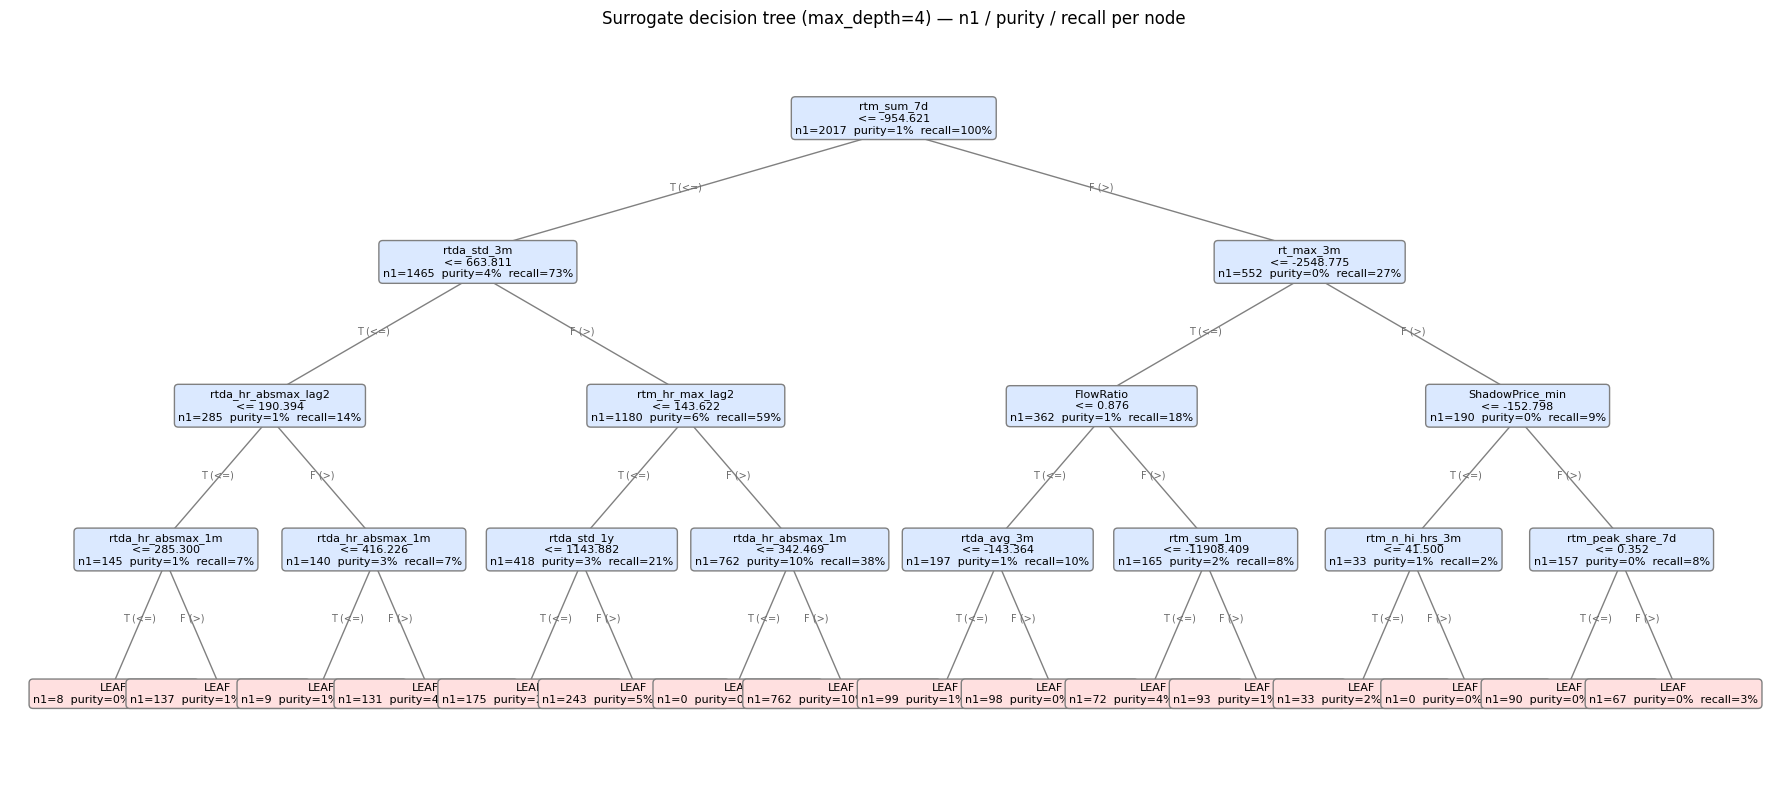

In [ ]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y = pos_xy[nd]
    tot = n1[nd] + n0[nd]; pur = n1[nd] / tot * 100 if tot else 0; rec = n1[nd] / pos * 100
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nn1={int(n1[nd])}  purity={pur:.0f}%  recall={rec:.0f}%'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate decision tree (max_depth=4) — n1 / purity / recall per node')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import (recall_score, precision_score, f1_score, accuracy_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

# ---------- 4) out-of-sample check on holdout_df ----------
dh = holdout_df.query('rtm_sum_1m<-200').dropna(subset=['bad_rtda']).copy()
yh = dh['bad_rtda'].astype(int)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

pos_h, N_h, base_h = int(yh.sum()), len(yh), yh.mean()
print(f'holdout_df: rows={N_h}  y=1={pos_h} ({base_h*100:.2f}%)')

def eval_model(name, model, X):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(yh, pred).ravel()
    print(f'\n=== {name} on holdout_df ===')
    print(f'  recall={recall_score(yh, pred):.3f}  precision={precision_score(yh, pred):.3f}  '
          f'f1={f1_score(yh, pred):.3f}  accuracy={accuracy_score(yh, pred):.3f}')
    print(f'  roc_auc={roc_auc_score(yh, proba):.3f}  pr_auc={average_precision_score(yh, proba):.3f}')
    print(f'  confusion: tp={tp} fn={fn} fp={fp} tn={tn}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=50893  y=1=814 (1.60%)

=== LightGBM on holdout_df ===
  recall=0.622  precision=0.105  f1=0.180  accuracy=0.909
  roc_auc=0.875  pr_auc=0.201
  confusion: tp=506 fn=308 fp=4308 tn=45771

=== RandomForest on holdout_df ===
  recall=0.644  precision=0.089  f1=0.157  accuracy=0.889
  roc_auc=0.869  pr_auc=0.204
  confusion: tp=524 fn=290 fp=5339 tn=44740


# Pinball loss on the rt-da 

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=186578  rt_da mean=-25.4  median=0.0  p1=-3176.3  p5=-429.0

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=60.42

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
rt_max_1y,0.1275
rtda_hr_abssum_7d,0.1087
rtm_sum_1y,0.0839
rtm_sum_7d,0.0837
rt_max_3m,0.0789
rtm_sum_1m,0.0674
FlowRatio,0.0588
rtm_n_hi_hrs_1m,0.0386
rtm_n_hi_hrs_3m,0.0351
rtm_peak_share_7d,0.0333



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.032


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [rtda_avg_3m <= -464.090]  mean=     -25.4  n_rows=186578
    T> [rtda_sum_7d <= -11724.632]  mean=    -587.8  n_rows= 4667
      T> [dam_sum_1y <= -15821.830]  mean=   -1478.0  n_rows=  919
        T> [dam_lag1 <= -3687.313]  mean=    -702.3  n_rows=  529
          T> LEAF  mean=     680.1  n_rows=  113
          F> LEAF  mean=   -1077.8  n_rows=  416
        F> [wind_forecast <= 16857.171]  mean=   -2530.3  n_rows=  390
          T> LEAF  mean=   -1937.4  n_rows=  290
          F> LEAF  mean=   -4249.5  n_rows=  100
      F> [rtda_sum_7d <= -673.205]  mean=    -369.5  n_rows= 3748
        T> [dam_lag1 <= -2135.391]  mean=    -605.1  n_rows= 1638
          T> LEAF  mean=     396.6  n_rows=  141
          F> LEAF  mean=    -699.4  n_rows= 1497
        F> [rtda_shape_corr_7d <= -0.119]  mean=    -186.7  n_rows= 2110
          T> LEAF  mean=    -625.9  n_rows=  210
          F> LEAF  mean=    -138.1  n_rows= 1900
    F> [dam_lag1 <

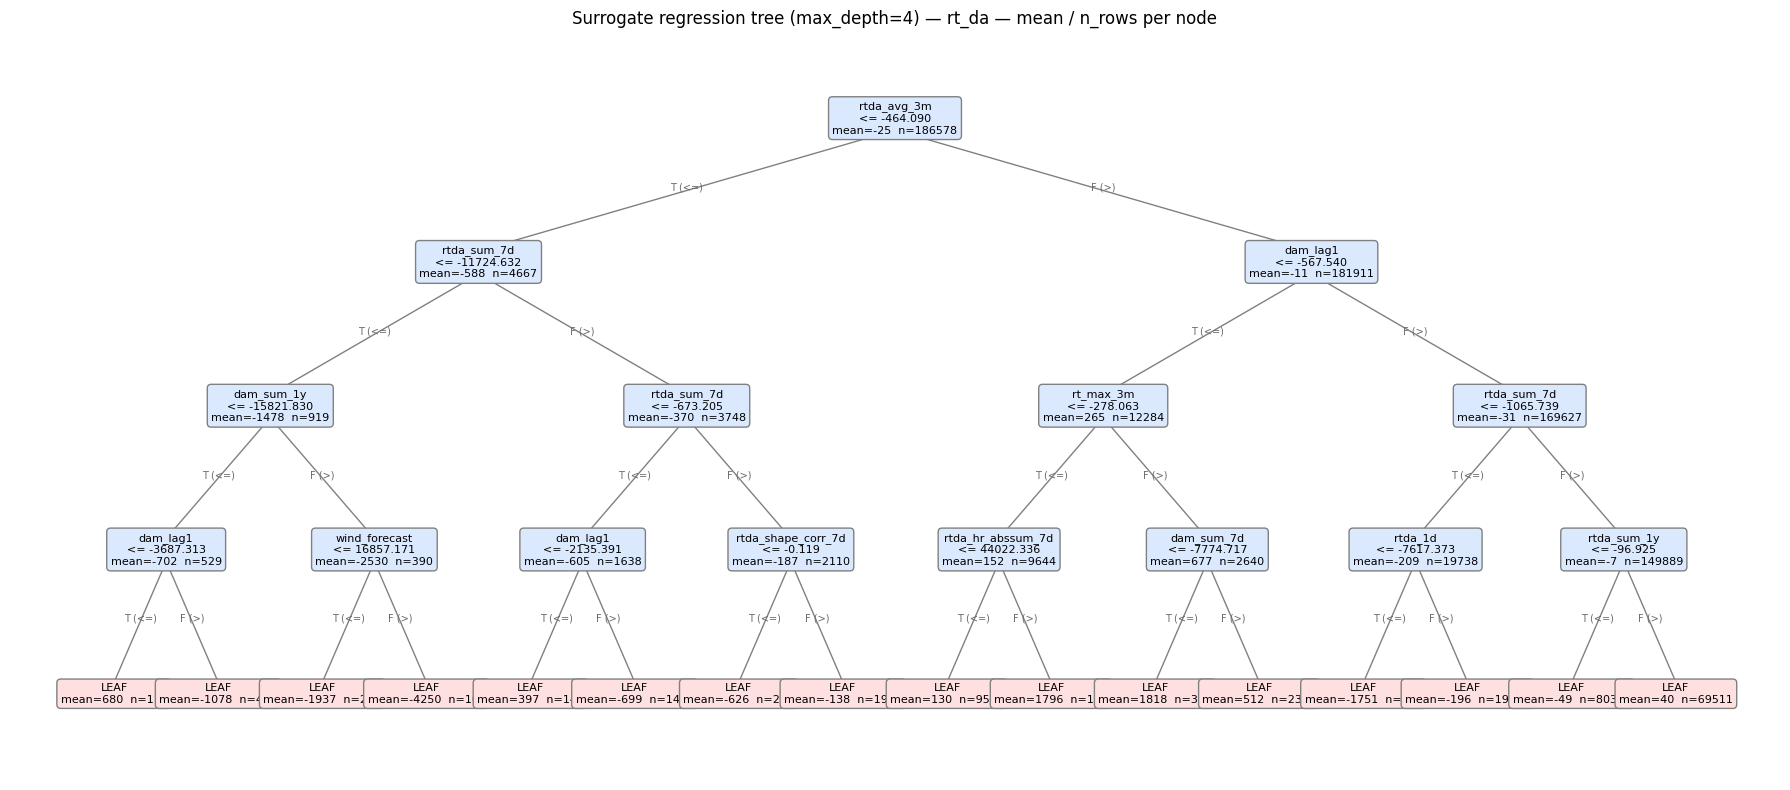

In [ ]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da — mean / n_rows per node')
plt.tight_layout()
plt.show()


# rerun without top variable 

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in (['rtm_sum_7d','rtda_sum_7d','rtm_sum_3m','rtda_avg_7d','rt_max_3m', 'long_profit_sum_1m','short_profit_sum_1m'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=80.67

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
dfax_absmax,0.1029
rtm_lag1,0.0668
FlowRatio,0.0639
rtm_sum_1m,0.0623
rt_nz_cnt_1m,0.0601
dfax_absmean,0.0442
wind_forecast,0.0418
rtda_std_1y,0.0389
rt_nz_cnt_1y,0.0367
rt_spike_3m,0.0362



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.045


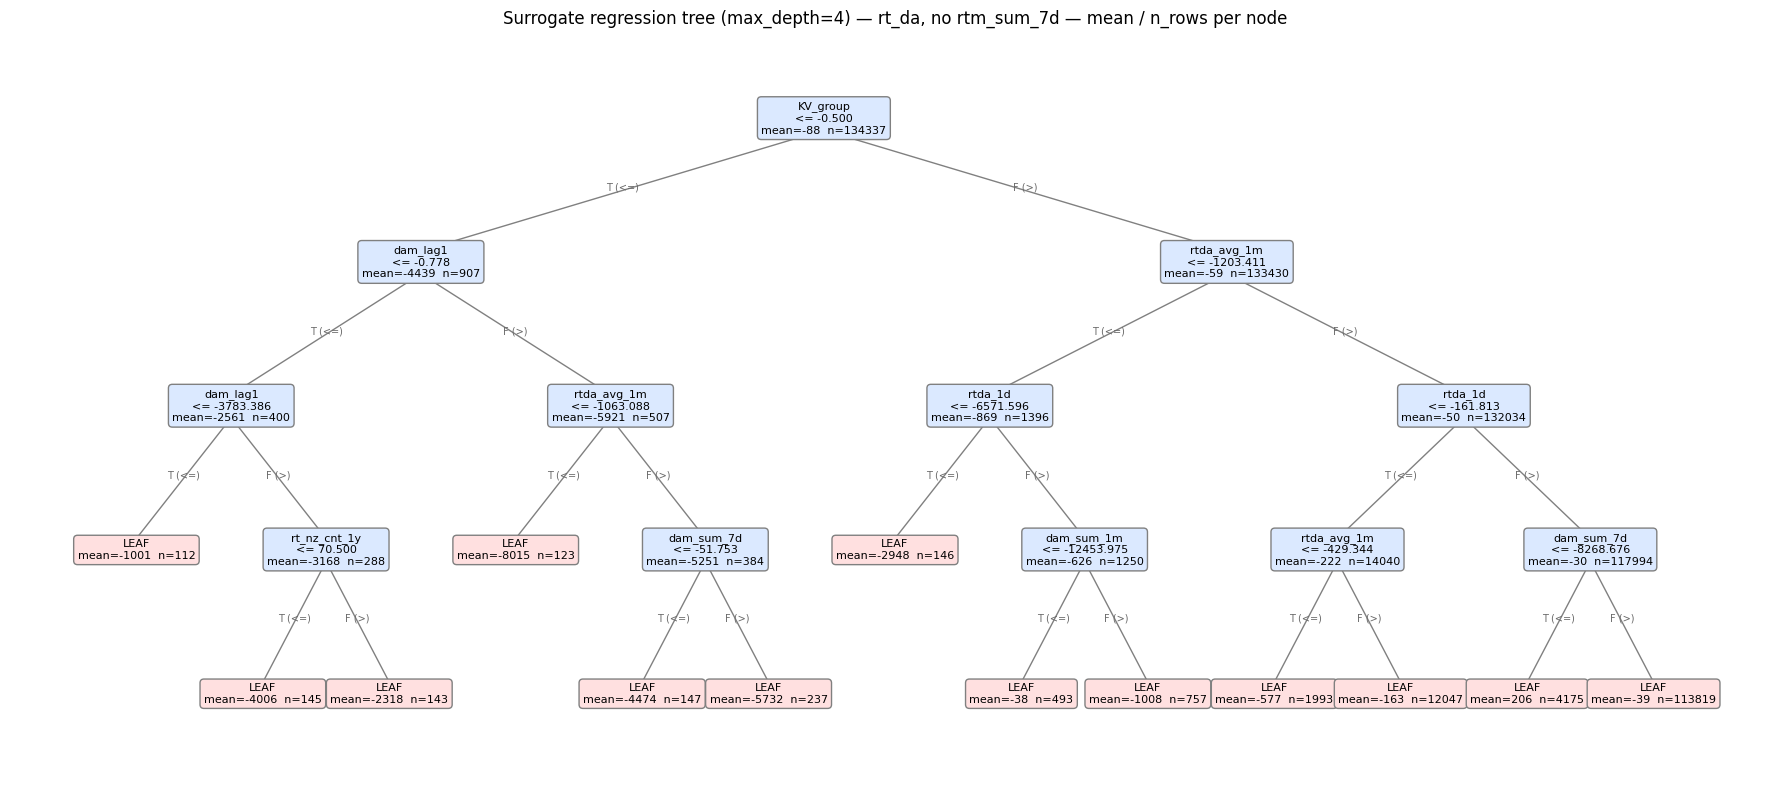

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -88.4  n_rows=134337
    T> [dam_lag1 <= -0.778]  mean=   -4439.4  n_rows=  907
      T> [dam_lag1 <= -3783.386]  mean=   -2561.2  n_rows=  400
        T> LEAF  mean=   -1001.1  n_rows=  112
        F> [rt_nz_cnt_1y <= 70.500]  mean=   -3167.9  n_rows=  288
          T> LEAF  mean=   -4006.3  n_rows=  145
          F> LEAF  mean=   -2317.7  n_rows=  143
      F> [rtda_avg_1m <= -1063.088]  mean=   -5921.2  n_rows=  507
        T> LEAF  mean=   -8015.0  n_rows=  123
        F> [dam_sum_7d <= -51.753]  mean=   -5250.6  n_rows=  384
          T> LEAF  mean=   -4473.8  n_rows=  147
          F> LEAF  mean=   -5732.4  n_rows=  237
    F> [rtda_avg_1m <= -1203.411]  mean=     -58.9  n_rows=133430
      T> [rtda_1d <= -6571.596]  mean=    -868.5  n_rows= 1396
        T> LEAF  mean=   -2948.2  n_rows=  146
        F> [dam_sum_1m <= -12453.975]  mean=    -625.6  n_rows= 1250
          T> LEAF  mean=     -38

# Rerun with selected variables: KV, FlowRatio, rtm_sum_7d, dam_sum_7d, rt_da_std_1m

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f  in (['FlowRatio'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=186578  rt_da mean=-25.4  median=0.0  p1=-3176.3  p5=-429.0

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=99.31

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
FlowRatio,0.8299
KV_group,0.1701



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.049


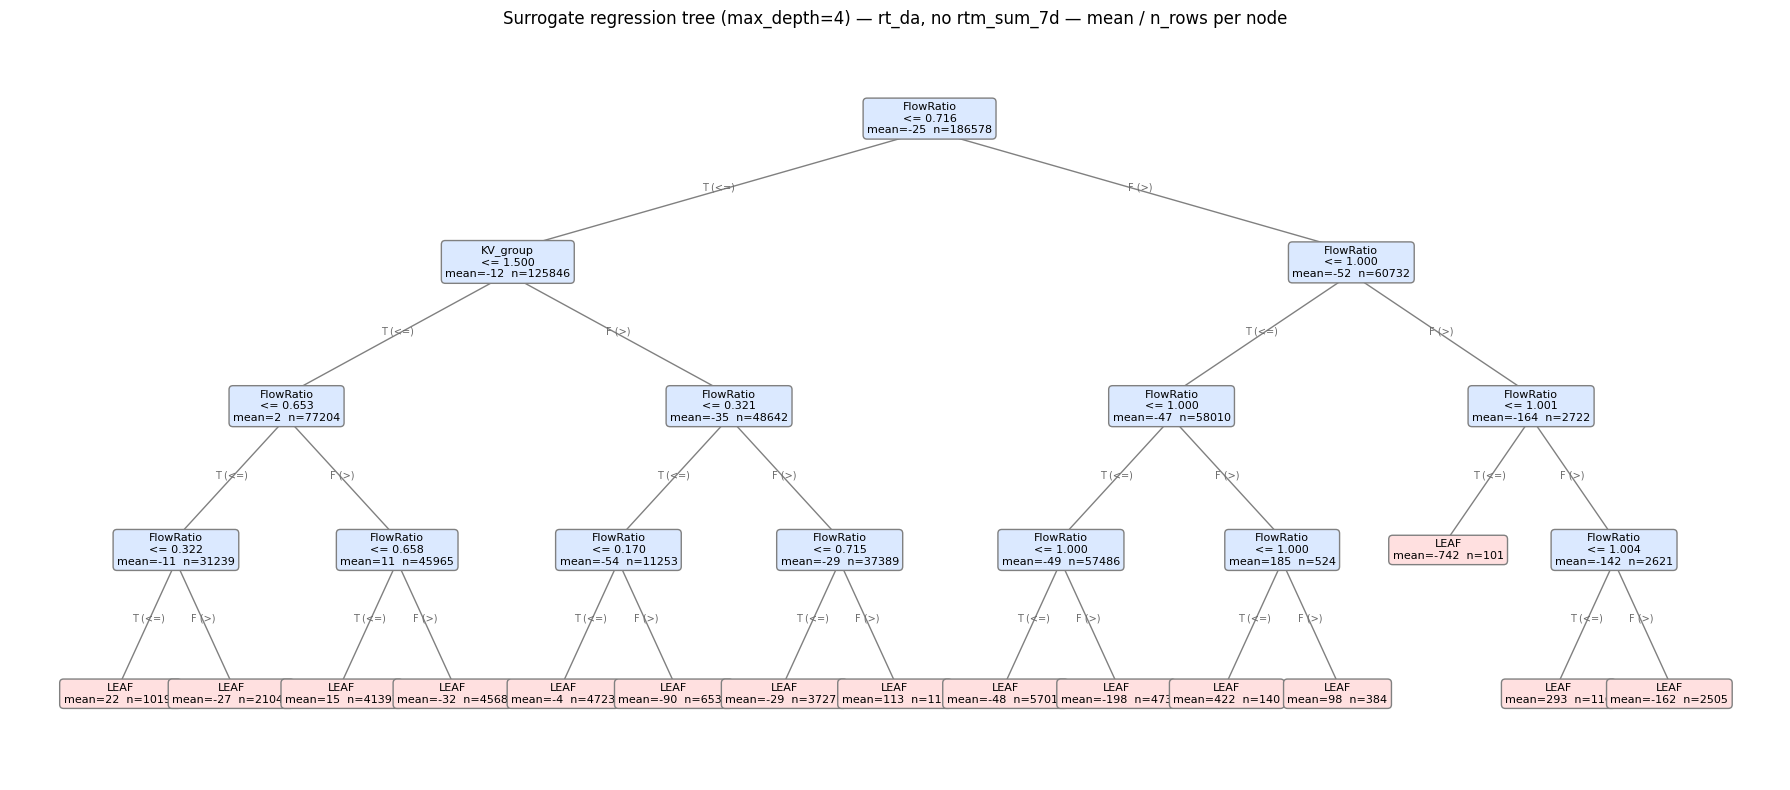

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Setting quantile to split the variables to see the rate of capturing. 

In [ ]:
# quantiles on negative short_profit at TAIL-WEIGHTED breakpoints (1%,5%,10%,30%,...)
#   bins 1..10: p0-1, p1-5, p5-10, p10-30, p30-50, p50-70, p70-90, p90-95, p95-99, p99-100
#   quantile 1 = worst 1% (most negative short loss)
train_df_filter['bad_shortprofit'] = (train_df_filter['short_profit'] < -20000).astype(int)
holdout_df_filter = holdout_df.query('rtm_sum_7d < -200 and dam_sum_7d < -500')
holdout_df_filter['bad_shortprofit'] = (holdout_df_filter['short_profit'] < -20000).astype(int)

In [ ]:
d = train_df_filter.dropna(subset=['rt_da', 'FlowRatio']).copy()
WORST = {1,2} 
# 10 equal-count FlowRatio buckets
d['FlowRatio_q'] = pd.qcut(d['FlowRatio'], q=10, duplicates='drop')

bucket = (d.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),
                    short_p1 = ('bad_shortprofit','sum')
                 ).round(2).reset_index())
bucket['ratio'] = bucket['bad_rtda']/bucket['n']
display(bucket)


,FlowRatio_q,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio
0,"(-0.001, 0.247]",14342,0.00,0.25,-12.56,0.0,-102.72,72,3,0.005020
1,"(0.247, 0.384]",14341,0.25,0.38,-30.18,0.0,-205.90,93,4,0.006485
2,"(0.384, 0.486]",14341,0.38,0.49,-11.55,0.0,-56.50,57,2,0.003975
3,"(0.486, 0.573]",14342,0.49,0.57,-34.89,0.0,-143.06,97,8,0.006763
4,"(0.573, 0.654]",14341,0.57,0.65,-44.36,0.0,-175.84,121,10,0.008437
5,"(0.654, 0.735]",14341,0.65,0.73,-37.14,0.0,-293.12,136,11,0.009483
6,"(0.735, 0.819]",14342,0.73,0.82,-51.75,0.0,-440.33,160,10,0.011156
7,"(0.819, 0.914]",14341,0.82,0.91,-46.67,0.0,-741.04,218,15,0.015201
8,"(0.914, 1.0]",24389,0.91,1.00,-46.32,0.0,-1407.91,569,91,0.023330
9,"(1.0, 1.733]",4294,1.00,1.73,-99.64,0.0,-3515.88,268,31,0.062413


In [ ]:
d = train_df_filter.dropna(subset=['rt_da', 'rtm_sum_7d']).copy()

WORST = {1,2}   # worst short_profit band (bottom 1% of negative short_profit); add 'p1-p5' to widen

# 10 equal-count rtda_hr_abssum_7d buckets
d['rtm_sum_7d_q'] = pd.qcut(d['rtm_sum_7d'], q=20, duplicates='drop')

bucket = (d.groupby('rtm_sum_7d_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda     = ('bad_rtda', 'sum'),
                  short_p1 = ('bad_shortprofit','sum')).round(2).reset_index())
bucket['ratio']      = bucket['bad_rtda'] / bucket['n']
bucket['p0p1_share'] = (bucket['short_p1'] / bucket['n']).round(3)
display(bucket)


,rtm_sum_7d_q,n,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio,p0p1_share
0,"(-130256.945, -7485.507]",9329,-234.35,0.0,-4518.79,755,83,0.080930,0.009
1,"(-7485.507, -3602.864]",9329,-171.19,0.0,-2233.06,318,37,0.034087,0.004
2,"(-3602.864, -2043.297]",9329,-120.63,0.0,-1437.85,199,22,0.021331,0.002
3,"(-2043.297, -1186.413]",9329,-102.44,0.0,-1103.82,137,18,0.014685,0.002
4,"(-1186.413, -673.337]",9332,-78.34,0.0,-821.55,106,11,0.011359,0.001
5,"(-673.337, -361.558]",9331,-66.03,0.0,-606.43,73,8,0.007823,0.001
6,"(-361.558, -154.457]",9326,-47.45,0.0,-437.99,68,11,0.007291,0.001
7,"(-154.457, -17.033]",9327,-29.54,0.0,-336.30,58,5,0.006219,0.001
8,"(-17.033, 0.0]",111946,28.57,0.0,0.00,303,27,0.002707,0.000


In [ ]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-3000')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['FlowRatio_q'] = pd.qcut(train_df_filter_temp['FlowRatio'], q=20, duplicates='drop')

bucket = (train_df_filter_temp.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),
                short_p1 = ('bad_shortprofit','sum')).round(2).reset_index()).round(2)

bucket['ratio']      = bucket['bad_rtda'] / bucket['n']
bucket['p0p1_share'] = (bucket['short_p1'] / bucket['n']).round(3)
display(bucket)

,FlowRatio_q,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio,p0p1_share
0,"(-0.001, 0.0969]",6217,0.00,0.10,20.77,0.0,0.00,11,2,0.001769,0.000
1,"(0.0969, 0.232]",6216,0.10,0.23,1.04,0.0,-140.55,16,0,0.002574,0.000
2,"(0.232, 0.307]",6217,0.23,0.31,2.61,0.0,-134.06,15,1,0.002413,0.000
3,"(0.307, 0.368]",6216,0.31,0.37,-7.61,0.0,-72.25,16,2,0.002574,0.000
4,"(0.368, 0.42]",6216,0.37,0.42,-12.71,0.0,-19.66,16,0,0.002574,0.000
5,"(0.42, 0.467]",6216,0.42,0.47,4.77,0.0,-0.65,11,0,0.001770,0.000
6,"(0.467, 0.511]",6216,0.47,0.51,-4.61,0.0,-27.34,20,2,0.003218,0.000
7,"(0.511, 0.552]",6217,0.51,0.55,-14.54,0.0,-29.79,27,2,0.004343,0.000
8,"(0.552, 0.592]",6216,0.55,0.59,-16.67,0.0,-38.92,13,0,0.002091,0.000
9,"(0.592, 0.631]",6216,0.59,0.63,-17.58,0.0,-29.81,24,2,0.003861,0.000


In [ ]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-3000 and FlowRatio < 1 ')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rtda_sum_1m_q'] = pd.qcut(train_df_filter_temp['dfax_absmax'], q=20, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtda_sum_1m_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
bucket['ratio']      = bucket['bad_rtda'] / bucket['n']
bucket['p0p1_share'] = (bucket['short_p1'] / bucket['n']).round(3)
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio,p0p1_share
rtda_sum_1m_q,,,,,,,,,,
"(0.0091, 0.0231]",5628,0.0,1.0,-35.63,0.0,-117.75,28,0,0.004975,0.000
"(0.0231, 0.0324]",5596,0.0,1.0,-31.93,0.0,-94.08,29,0,0.005182,0.000
"(0.0324, 0.0437]",5672,0.0,1.0,-26.46,0.0,-57.15,25,0,0.004408,0.000
"(0.0437, 0.0547]",5517,0.0,1.0,-15.69,0.0,-71.92,13,1,0.002356,0.000
"(0.0547, 0.0653]",5586,0.0,1.0,-13.80,0.0,-48.92,15,1,0.002685,0.000
"(0.0653, 0.0794]",5663,0.0,1.0,-6.67,0.0,-20.79,23,0,0.004061,0.000
"(0.0794, 0.0942]",5559,0.0,1.0,-25.08,0.0,-89.12,36,1,0.006476,0.000
"(0.0942, 0.11]",5583,0.0,1.0,-25.56,0.0,-106.18,29,1,0.005194,0.000
"(0.11, 0.126]",5662,0.0,1.0,9.68,0.0,-68.60,14,0,0.002473,0.000


In [ ]:
import pandas as pd, numpy as np
d = train_df_filter.copy()

# quantile buckets; keep NaN FlowRatio (~60% of rows) as its own visible bucket
d['nz3y_q'] = pd.qcut(d['rt_nz_cnt_3y'], 20, duplicates='drop')
d['fr_q']   = pd.qcut(d['FlowRatio'],    20, duplicates='drop').cat.add_categories('NaN')
d['fr_q']   = d['fr_q'].fillna('NaN')

base, P = d['bad_rtda'].mean(), d['bad_rtda'].sum()
print(f"base bad_rtda rate = {base:.3%}   total positives = {int(P)}")

rate   = d.pivot_table('bad_rtda', 'nz3y_q', 'fr_q', 'mean', observed=True)
recall = d.pivot_table('bad_rtda', 'nz3y_q', 'fr_q', 'sum',  observed=True) / P
cnt    = d.pivot_table('bad_rtda', 'nz3y_q', 'fr_q', 'size', observed=True)

print("\n=== RATE: bad_rtda % within each cell ===");        display((rate*100).round(2))
print("=== LIFT: rate ÷ base (how many× worse than avg) ==="); display((rate/base).round(1))
print("=== RECALL: % of ALL bad_rtda in each cell ===");      display((recall*100).round(1))
print("=== rows per cell ===");                               display(cnt)


base bad_rtda rate = 0.160%   total positives = 2254

=== RATE: bad_rtda % within each cell ===


fr_q,"(-0.001, 0.000563]","(0.000563, 0.167]","(0.167, 0.236]","(0.236, 0.286]","(0.286, 0.33]","(0.33, 0.37]","(0.37, 0.408]","(0.408, 0.443]","(0.443, 0.477]","(0.477, 0.511]",...,"(0.546, 0.583]","(0.583, 0.621]","(0.621, 0.662]","(0.662, 0.707]","(0.707, 0.757]","(0.757, 0.815]","(0.815, 0.886]","(0.886, 0.99]","(0.99, 2.015]",NaN
nz3y_q,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 1.0]",0.01,0.02,0.01,0.03,0.04,0.01,0.05,0.01,0.01,0.01,...,0.00,0.02,0.07,0.10,0.08,0.07,0.00,0.20,0.17,0.01
"(1.0, 2.0]",0.00,0.07,0.00,0.00,0.00,0.08,0.00,0.09,0.00,0.00,...,0.09,0.00,0.09,0.12,0.23,0.00,0.18,0.93,2.03,0.07
"(2.0, 3.0]",0.00,0.00,0.00,0.06,0.00,0.00,0.08,0.00,0.00,0.00,...,0.00,0.00,0.11,0.00,0.38,0.00,0.37,0.50,0.40,0.08
"(3.0, 5.0]",0.00,0.00,0.00,0.14,0.10,0.05,0.00,0.10,0.00,0.00,...,0.13,0.13,0.07,0.14,0.14,0.08,0.39,0.41,1.29,0.08
"(5.0, 8.0]",0.00,0.00,0.05,0.00,0.05,0.05,0.04,0.05,0.14,0.09,...,0.09,0.18,0.05,0.26,0.28,0.06,0.13,0.24,0.85,0.07
"(8.0, 12.0]",0.00,0.00,0.19,0.00,0.12,0.00,0.05,0.00,0.05,0.05,...,0.25,0.15,0.15,0.10,0.21,0.05,0.40,0.43,0.56,0.13
"(12.0, 18.0]",0.12,0.15,0.04,0.04,0.04,0.09,0.14,0.10,0.10,0.20,...,0.24,0.15,0.05,0.19,0.10,0.21,0.21,0.51,1.29,0.19
"(18.0, 28.0]",0.05,0.06,0.00,0.10,0.00,0.10,0.14,0.09,0.04,0.21,...,0.08,0.23,0.15,0.12,0.30,0.32,0.32,0.83,1.52,0.18
"(28.0, 46.0]",0.20,0.00,0.05,0.05,0.23,0.14,0.05,0.13,0.09,0.31,...,0.16,0.22,0.37,0.38,0.77,0.41,0.51,0.82,1.34,0.21


=== LIFT: rate ÷ base (how many× worse than avg) ===


fr_q,"(-0.001, 0.000563]","(0.000563, 0.167]","(0.167, 0.236]","(0.236, 0.286]","(0.286, 0.33]","(0.33, 0.37]","(0.37, 0.408]","(0.408, 0.443]","(0.443, 0.477]","(0.477, 0.511]",...,"(0.546, 0.583]","(0.583, 0.621]","(0.621, 0.662]","(0.662, 0.707]","(0.707, 0.757]","(0.757, 0.815]","(0.815, 0.886]","(0.886, 0.99]","(0.99, 2.015]",NaN
nz3y_q,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 1.0]",0.1,0.2,0.1,0.2,0.2,0.1,0.3,0.1,0.1,0.1,...,0.0,0.1,0.4,0.6,0.5,0.4,0.0,1.3,1.1,0.1
"(1.0, 2.0]",0.0,0.5,0.0,0.0,0.0,0.5,0.0,0.6,0.0,0.0,...,0.5,0.0,0.6,0.7,1.4,0.0,1.1,5.8,12.7,0.4
"(2.0, 3.0]",0.0,0.0,0.0,0.4,0.0,0.0,0.5,0.0,0.0,0.0,...,0.0,0.0,0.7,0.0,2.4,0.0,2.3,3.1,2.5,0.5
"(3.0, 5.0]",0.0,0.0,0.0,0.9,0.6,0.3,0.0,0.6,0.0,0.0,...,0.8,0.8,0.4,0.9,0.9,0.5,2.4,2.5,8.0,0.5
"(5.0, 8.0]",0.0,0.0,0.3,0.0,0.3,0.3,0.3,0.3,0.9,0.6,...,0.5,1.1,0.3,1.6,1.8,0.4,0.8,1.5,5.3,0.4
"(8.0, 12.0]",0.0,0.0,1.2,0.0,0.8,0.0,0.3,0.0,0.3,0.3,...,1.5,0.9,0.9,0.6,1.3,0.3,2.5,2.7,3.5,0.8
"(12.0, 18.0]",0.7,0.9,0.3,0.3,0.3,0.5,0.9,0.6,0.6,1.2,...,1.5,0.9,0.3,1.2,0.6,1.3,1.3,3.2,8.0,1.2
"(18.0, 28.0]",0.3,0.4,0.0,0.6,0.0,0.6,0.9,0.6,0.3,1.3,...,0.5,1.5,0.9,0.7,1.9,2.0,2.0,5.1,9.5,1.1
"(28.0, 46.0]",1.2,0.0,0.3,0.3,1.5,0.9,0.3,0.8,0.5,1.9,...,1.0,1.4,2.3,2.4,4.8,2.6,3.2,5.1,8.4,1.3


=== RECALL: % of ALL bad_rtda in each cell ===


fr_q,"(-0.001, 0.000563]","(0.000563, 0.167]","(0.167, 0.236]","(0.236, 0.286]","(0.286, 0.33]","(0.33, 0.37]","(0.37, 0.408]","(0.408, 0.443]","(0.443, 0.477]","(0.477, 0.511]",...,"(0.546, 0.583]","(0.583, 0.621]","(0.621, 0.662]","(0.662, 0.707]","(0.707, 0.757]","(0.757, 0.815]","(0.815, 0.886]","(0.886, 0.99]","(0.99, 2.015]",NaN
nz3y_q,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 1.0]",0.0,0.1,0.0,0.1,0.1,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.2,0.2,0.2,0.1,0.0,0.3,0.1,2.2
"(1.0, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.2,0.3,0.7
"(2.0, 3.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.1,0.0,0.5
"(3.0, 5.0]",0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.1,0.0,0.0,...,0.1,0.1,0.0,0.1,0.1,0.0,0.2,0.2,0.3,0.8
"(5.0, 8.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,...,0.1,0.2,0.0,0.2,0.2,0.0,0.1,0.1,0.3,0.5
"(8.0, 12.0]",0.0,0.0,0.1,0.0,0.1,0.0,0.0,0.0,0.0,0.0,...,0.2,0.1,0.1,0.1,0.2,0.0,0.3,0.3,0.3,1.0
"(12.0, 18.0]",0.1,0.1,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.2,...,0.2,0.1,0.0,0.2,0.1,0.2,0.2,0.4,0.8,1.2
"(18.0, 28.0]",0.0,0.0,0.0,0.1,0.0,0.1,0.1,0.1,0.0,0.2,...,0.1,0.3,0.2,0.1,0.4,0.4,0.4,0.8,1.4,0.9
"(28.0, 46.0]",0.2,0.0,0.0,0.0,0.2,0.1,0.0,0.1,0.1,0.3,...,0.2,0.3,0.4,0.5,1.0,0.5,0.7,1.0,1.6,0.8


=== rows per cell ===


fr_q,"(-0.001, 0.000563]","(0.000563, 0.167]","(0.167, 0.236]","(0.236, 0.286]","(0.286, 0.33]","(0.33, 0.37]","(0.37, 0.408]","(0.408, 0.443]","(0.443, 0.477]","(0.477, 0.511]",...,"(0.546, 0.583]","(0.583, 0.621]","(0.621, 0.662]","(0.662, 0.707]","(0.707, 0.757]","(0.757, 0.815]","(0.815, 0.886]","(0.886, 0.99]","(0.99, 2.015]",NaN
nz3y_q,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 1.0]",11187,12077,7835,7750,7833,8137,8284,8404,8055,7506,...,6562,6081,5791,5154,4740,4433,3974,2986,1743,425787
"(1.0, 2.0]",416,1380,1353,1256,1296,1264,1164,1116,1088,1112,...,1142,1106,1075,843,880,694,546,431,295,21825
"(2.0, 3.0]",374,1330,1941,1699,1447,1375,1304,1293,1241,1111,...,963,955,870,867,780,733,534,400,253,14056
"(3.0, 5.0]",948,1207,2002,2091,2095,2106,2094,1953,1896,1802,...,1583,1520,1477,1434,1411,1309,1030,987,544,20481
"(5.0, 8.0]",1704,2262,2126,2171,2059,2047,2230,2115,2123,2209,...,2297,2223,2052,1948,1771,1664,1504,1254,709,18339
"(8.0, 12.0]",1902,1560,1548,1519,1663,1667,1861,1841,1988,2100,...,2016,2062,2061,1985,1864,1820,1753,1639,1257,18170
"(12.0, 18.0]",1710,1340,2474,2422,2388,2312,2100,2010,2038,2015,...,2041,1975,2047,2091,2093,1937,1928,1772,1397,14297
"(18.0, 28.0]",1871,1699,1836,1950,2077,2087,2164,2248,2271,2380,...,2490,2581,2645,2593,2693,2495,2476,2302,2112,11234
"(28.0, 46.0]",1998,1279,1964,2070,2137,2128,2130,2263,2274,2268,...,2542,2670,2705,2898,2973,2923,2941,2804,2609,8565


In [ ]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-3000 and FlowRatio < 1 ') 
train_df_filter_temp2 = train_df_filter_temp.query('rt_max_3m < -3000 ')

for col in ['bad_rtda', 'bad_shortprofit']:
    T_train_df_filter, T_pop, caught = int(train_df_filter[col].sum()), int(train_df_filter_temp[col].sum()), int(train_df_filter_temp2[col].sum())
    print(f"{col}:")
    print(f"   caught by rule            : {caught}")
    print(f"   left out within subset    : {T_pop - caught:>4}  ({(T_pop-caught)/T_pop:.1%} of subset positives)")
    print(f"   left out incl. pre-filter : {T_train_df_filter - caught:>4}  ({(T_train_df_filter-caught)/T_full:.1%} of ALL positives)")
print(train_df_filter_temp2.bad_rtda.sum()/len(train_df_filter_temp2))

bad_rtda:
   caught by rule            : 351
   left out within subset    :  200  (36.3% of subset positives)


NameError: name 'T_full' is not defined

In [ ]:
train_df_filter.query('rtm_sum_7d>-3000 and (FlowRatio < 1 or FlowRatio!=FlowRatio) ').sort_values(['short_profit'])[:20][['dt','monitored_name','short_profit','FlowRatio','rtm_sum_7d','rtm_sum_1m','rtm_sum_3m','dam_lag1','rt_da','dfax_absmax']]

,dt,monitored_name,short_profit,FlowRatio,rtm_sum_7d,rtm_sum_1m,rtm_sum_3m,dam_lag1,rt_da,dfax_absmax
1185946,2024-06-19,multi-elementconstraint.spsnmties.spsnmties,-160068.635807,NaN,-1252.9967,-12755.3894,-70242.9176,0.0000,-14163.9702,0.86240
975821,2024-10-15,multi-elementconstraint.spsnmties.spsnmties,-134924.559715,NaN,0.0000,-30351.6292,-61676.7488,-58.6323,-4437.3239,0.86240
154108,2024-09-11,multi-elementconstraint.spsnmties.spsnmties,-106097.029420,NaN,-154.6862,-8661.9343,-42685.0380,-979.5686,-3238.8748,0.83510
1111832,2024-05-31,multi-elementconstraint.spsnmties.spsnmties,-94757.188171,NaN,-0.4888,-23.0755,-61215.9749,-32.6762,-6710.4625,0.83510
8957,2024-01-24,xfmrsub975-sub975,-90358.895970,0.694529,-1717.9009,-3567.0490,-8851.2087,-3055.0976,-2915.5700,0.73490
413839,2024-11-03,multi-elementconstraint.spsnmties.spsnmties,-82599.470338,NaN,-2609.5696,-33856.2973,-93844.2337,-512.1515,-7743.4091,0.83510
426540,2024-06-17,lnmidj-lec,-72241.473715,0.945252,0.0000,0.0000,0.0000,-6.2953,-9930.9476,0.58629
966628,2026-04-09,lnhobbs-cunnsub,-69682.299411,0.000000,-1722.5198,-22087.4037,-31294.3359,-1019.4497,-10340.9621,0.46290
296438,2024-11-12,lndvisn-mstng1,-61622.628728,NaN,-1754.3970,-33278.2053,-83301.0145,-775.7190,-10429.1578,0.37460
1050218,2023-12-03,multi-elementconstraint.sppspsties.sppspsties,-60773.408483,NaN,-317.2206,-2420.6024,-6155.7447,0.0000,-2586.1836,0.88450


In [ ]:
train_df_filter.query('rtm_sum_7d>-3000 and (FlowRatio < 1 or FlowRatio!=FlowRatio) ').query('short_profit < 300')[['dt','monitored_name','short_profit','FlowRatio','rtm_sum_7d','rtm_sum_1m','rtm_sum_3m','dam_lag1','dfax_absmax']].dfax_absmax.mean()

np.float64(0.29070884379382894)

In [ ]:
train_df_filter_temp2 = train_df_filter_temp.query('rt_max_3m > -2600  or  rtda_hr_abssum_7d < 380')
train_df_filter_temp.query('bad_rtda == 1').sort_values(['rt_da']).head()[['dt','monitored_name','rtm','dam']]

,dt,monitored_name,rtm,dam
1258503,2024-04-15,lnredbluff-rdrunner,-28764.9674,0.0000
447715,2026-02-05,xfmrmorris-morris,-25084.1580,0.0000
223042,2024-02-27,lnredbluff-rdrunner,-29130.5032,-6730.0251
740276,2024-04-14,lnredbluff-rdrunner,-19725.5069,0.0000
594947,2024-10-29,lndvisn-mstng1,-18945.6964,-311.4903


In [ ]:
train_df_filter_temp.query('rt_max_3m < -2600  and  rtda_hr_abssum_7d > 380 and wind_forecast >15000 and bad_shortprofit == 1').short_profit


90574     -22864.032933
111240    -21457.241466
297106    -23435.394581
297110    -29678.676878
445035    -33292.575298
573331    -23034.700868
592773    -26930.115500
596103    -23948.808959
897580    -22687.462900
967727    -69682.299411
1053935   -20652.705743
1101777   -47009.784748
1263818   -35996.561927
Name: short_profit, dtype: float64

In [ ]:
holdout_df_filter_rest = holdout_df_filter.query(
    '(rtm_sum_7d >= -3000) and (FlowRatio <= 1  or FlowRatio != FlowRatio ) '
    'and ((rt_max_3m >= -2600) or (rtda_hr_abssum_7d <= 380))')

holdout_df_filter_rest.query('bad_shortprofit == 1 and short_profit<-50000')

,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,...,dfax_min,dfax_mean,dfax_std,dfax_absmean,dfax_pos_cnt,dfax_neg_cnt,dfax_strong,dfax_range,dfax_absmax,bad_shortprofit
175864,2024-03-21,904,89504.38028,105932.21146,747.593203,1771.244524,84.37530,1266.06336,21099.432464,-363747.582727,...,-0.0563,-0.012633,0.179479,0.083243,4.0,91.0,0.894737,0.9187,0.8624,1
292804,2021-09-20,904,-47657.83761,34362.49326,375.567656,845.073088,155.89583,335.75650,46174.108328,-95396.428950,...,-0.0538,-0.039830,0.092685,0.057704,2.0,191.0,0.917098,0.9162,0.8624,1
349349,2024-03-22,904,76267.30976,85765.35449,846.344978,1472.488934,248.07706,104.82227,139141.357411,-108059.792822,...,-0.0565,-0.013528,0.177850,0.082421,4.0,94.0,0.918367,0.9189,0.8624,1


In [ ]:
display('total_badrtda:', holdout_df_filter.bad_rtda.sum())
display('total_badshortprofit:', holdout_df_filter.bad_shortprofit.sum())
display('total_rows:', len(holdout_df_filter))

holdout_df_filter_temp = holdout_df_filter.query('(rtm_sum_7d < -3000) or (FlowRatio > 1) or (rt_max_3m <-2600 and rtda_hr_abssum_7d>380) ')
display('total_badrtda captured', holdout_df_filter_temp.bad_rtda.sum())
display('total_badshortprofit captured', holdout_df_filter_temp.bad_shortprofit.sum())
display('total_rows', len(holdout_df_filter_temp))


'total_badrtda:'

np.int64(414)

'total_badshortprofit:'

np.int64(57)

'total_rows:'

...

np.int64(398)

'total_badshortprofit captured'

np.int64(49)

'total_rows'

9302

In [ ]:
train_df_filter_temp = train_df_filter.query('rtda_hr_abssum_7d<3000 and FlowRatio < 1 and wind_forecast > 15000')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rtda_sum_1m_q'] = pd.qcut(train_df_filter_temp['rtda_hr_abssum_1m'], q=20, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtda_sum_1m_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1
rtda_sum_1m_q,,,,,,,,
"(117.952, 333.927]",1570,0.0,1.0,-32.56,0.0,-117.33,4,1
"(333.927, 484.854]",1568,0.0,1.0,-64.07,0.0,-188.55,8,0
"(484.854, 648.147]",1569,0.0,1.0,-20.81,0.0,-56.01,3,1
"(648.147, 861.4]",1569,0.0,1.0,-31.07,0.0,-138.71,4,0
"(861.4, 1079.249]",1567,0.0,1.0,-35.89,0.0,-141.50,7,2
"(1079.249, 1354.257]",1571,0.0,1.0,-36.34,0.0,-241.99,6,0
"(1354.257, 1631.412]",1567,0.0,1.0,-42.90,0.0,-165.85,7,1
"(1631.412, 1939.927]",1568,0.0,1.0,-57.11,0.0,-404.88,8,1
"(1939.927, 2313.097]",1569,0.0,1.0,-61.40,0.0,-394.13,13,0


In [ ]:
train_df_filter_temp = train_df_filter.query('rtda_hr_abssum_7d<3000 and FlowRatio < 1 ')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rtda_sum_1m_q'] = pd.qcut(train_df_filter_temp['rtda_sum_1y'], q=20, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtda_sum_1m_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1
rtda_sum_1m_q,,,,,,,,
"(-850877.859, -74439.668]",4056,0.0,1.0,-191.42,0.0,-1342.55,72,3
"(-74439.668, -45900.407]",4060,0.0,1.0,-115.90,0.0,-616.21,46,2
"(-45900.407, -33814.607]",4043,0.0,1.0,-87.11,0.0,-521.38,36,2
"(-33814.607, -25430.588]",4056,0.0,1.0,-58.39,0.0,-434.89,21,1
"(-25430.588, -19781.117]",4070,0.0,1.0,-64.68,0.0,-416.59,25,0
"(-19781.117, -15323.974]",4045,0.0,1.0,-59.25,0.0,-421.91,21,1
"(-15323.974, -11778.958]",4040,0.0,1.0,-53.86,0.0,-311.92,25,1
"(-11778.958, -9202.013]",4053,0.0,1.0,-44.30,0.0,-264.82,13,1
"(-9202.013, -7217.33]",4064,0.0,1.0,-49.15,0.0,-215.01,23,2


In [ ]:
train_df_filter_temp = train_df_filter.query('rtda_hr_abssum_7d<3000 and FlowRatio < 1 ')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rtda_sum_1m_q'] = pd.qcut(train_df_filter_temp['rt_nz_cnt_1y'], q=20, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtda_sum_1m_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1
rtda_sum_1m_q,,,,,,,,
"(0.999, 2.0]",4520,0.0,1.0,-32.51,0.0,0.00,22,0
"(2.0, 4.0]",4402,0.0,1.0,-5.66,0.0,0.00,13,0
"(4.0, 6.0]",4356,0.0,1.0,-4.80,0.0,0.00,9,1
"(6.0, 8.0]",3821,0.0,1.0,-23.71,0.0,0.00,17,1
"(8.0, 11.0]",4686,0.0,1.0,-34.48,0.0,-41.99,20,2
"(11.0, 13.0]",2638,0.0,1.0,-21.82,0.0,-79.04,9,0
"(13.0, 16.0]",3983,0.0,1.0,-12.61,0.0,-51.23,15,3
"(16.0, 20.0]",4309,0.0,1.0,-39.11,0.0,-167.38,32,3
"(20.0, 24.0]",3945,0.0,1.0,-52.55,0.0,-194.15,19,1


In [ ]:
train_df_filter_temp = train_df_filter
# 10 equal-count FlowRatio buckets
train_df_filter['rtda_sum_1m_abs'] = train_df_filter['rtda_sum_1m'].abs()
train_df_filter_temp['rtda_sum_1m_q'] = pd.qcut(train_df_filter_temp['rtda_sum_1m_abs'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtda_sum_1m_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1
rtda_sum_1m_q,,,,,,,,
"(0.0751, 280.156]",13433,0.0,1.39,-15.92,0.0,-156.67,44,7
"(280.156, 529.74]",13445,0.0,1.47,-28.92,0.0,-175.25,56,7
"(529.74, 854.819]",13418,0.0,1.64,-30.32,0.0,-225.17,72,13
"(854.819, 1295.582]",13444,0.0,1.67,-37.43,0.0,-303.73,82,5
"(1295.582, 1916.939]",13423,0.0,1.63,-42.99,0.0,-462.14,97,7
"(1916.939, 2852.144]",13431,0.0,1.64,-48.65,0.0,-572.36,130,14
"(2852.144, 4170.044]",13430,0.0,1.59,-51.53,0.0,-704.19,151,23
"(4170.044, 6560.263]",13431,0.0,1.60,-64.34,0.0,-942.04,210,31
"(6560.263, 11779.558]",13431,0.0,1.64,-84.95,0.0,-1448.62,306,36


In [ ]:
train_df_filter_temp = train_df_filter
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rtm_hhi_lag2_q'] = pd.qcut(train_df_filter_temp['rtda_shape_corr_7d'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rtm_hhi_lag2_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),short_p1 = ('bad_shortprofit','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1
rtm_hhi_lag2_q,,,,,,,,
"(-1.001, -0.513]",4848,0.0,1.58,-61.39,0.0,-658.12,55,3
"(-0.513, -0.39]",4845,0.0,1.55,-85.31,0.0,-1003.87,92,7
"(-0.39, -0.295]",4846,0.0,1.53,-41.78,0.0,-908.45,90,10
"(-0.295, -0.194]",4846,0.0,1.58,-67.14,0.0,-1239.05,102,11
"(-0.194, -0.0742]",4846,0.0,1.64,-49.86,0.0,-1378.41,105,19
"(-0.0742, 0.0568]",4846,0.0,1.53,-11.73,0.0,-1517.66,123,23
"(0.0568, 0.186]",4847,0.0,1.56,9.80,0.0,-1574.77,130,23
"(0.186, 0.332]",4845,0.0,1.60,-70.77,0.0,-1768.78,140,18
"(0.332, 0.506]",4846,0.0,1.63,-2.08,0.0,-1571.54,140,23


In [ ]:
d = train_df_filter.dropna(subset=['rt_da', 'rt_nz_cnt_1y']).copy()

# 10 equal-count FlowRatio buckets
d['rt_nz_cnt_1y_q'] = pd.qcut(d['rt_nz_cnt_1y'], q=10, duplicates='drop')

bucket = (d.groupby('rt_nz_cnt_1y_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)


,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
rt_nz_cnt_1y_q,,,,,,,
"(0.999, 4.0]",15503,0.0,1.64,-54.19,0.0,-17.54,142
"(4.0, 8.0]",12742,0.0,1.47,-46.51,0.0,-105.06,122
"(8.0, 14.0]",13132,0.0,1.64,-59.34,0.0,-340.49,181
"(14.0, 22.0]",13475,0.0,1.59,-73.27,0.0,-428.57,182
"(22.0, 31.0]",12551,0.0,1.63,-85.07,0.0,-639.09,193
"(31.0, 42.0]",13801,0.0,1.73,-73.06,0.0,-706.45,235
"(42.0, 58.0]",13544,0.0,1.46,-85.96,0.0,-957.21,266
"(58.0, 78.0]",13040,0.0,1.67,-99.70,0.0,-1001.35,251
"(78.0, 118.0]",13170,0.0,1.64,-119.19,0.0,-1371.45,296


# Run on the sample rtm_sum_7d>-3000 and flowratio <1 

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

# rows NOT captured by the top cut
d = train_df_filter.query('rtm_sum_7d > -3000 and FlowRatio <1').dropna(subset=['rtda_hr_abssum_7d','FlowRatio']).copy()
y = d['rt_da'].astype(float)

# drop rtm_sum_7d itself (near-constant / already used) + long/short profit handled upstream
FEATS = [f for f in globals().get('compact', features) if f not in ['rtm_sum_7d', 'FlowRatio']]
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# ---------- feature importance (tau=0.05 quantile model) ----------
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
m = lgb.LGBMRegressor(objective='quantile', alpha=0.05, n_estimators=400, learning_rate=0.05,
                      num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                      random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)
imp = pd.Series(m.booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===')
display(imp.head(15).round(4).to_frame('gain'))

# ---------- surrogate tree: mean rt_da / n_rows at each node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_; node_mean = t.value[:, 0, 0]; node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>6}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> '); show(t.children_right[nd], dep+1, 'F> ')
show()

# ---------- leaf rules ranked by worst mean rt_da ----------
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),'rule':rules[i]} for i in leaves])
       .sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>6}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=112334  rt_da mean=-13.0  median=0.0  p1=-1674.8  p5=-141.4

=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===


,gain
rtm_n_hi_hrs_3m,0.1406
rtm_n_hi_hrs_1m,0.0924
rtda_hr_abssum_7d,0.0792
rt_max_3m,0.0791
rtm_peak_share_7d,0.0562
rtda_sum_1y,0.0455
rtm_sum_1y,0.0405
rt_max_1y,0.0337
rtm_sum_1m,0.0326
rtda_shape_corr_3m,0.0267



=== tree splits: mean rt_da / n_rows at EACH node ===
  [dam_sum_7d <= -9264.547]  mean=     -13.0  n_rows=112334
    T> [rtm_n_hi_hrs_3m <= 1.500]  mean=     858.8  n_rows=   617
      T> [dam_lag1 <= -1246.403]  mean=    1754.2  n_rows=   204
        T> LEAF  mean=    2696.5  n_rows=   102
        F> LEAF  mean=     811.9  n_rows=   102
      F> [dam_lag1 <= -1930.258]  mean=     416.5  n_rows=   413
        T> LEAF  mean=     983.7  n_rows=   101
        F> [rtda_sum_1y <= 15341.930]  mean=     232.8  n_rows=   312
          T> LEAF  mean=       1.1  n_rows=   137
          F> LEAF  mean=     414.2  n_rows=   175
    F> [rtda_sum_1y <= -66.582]  mean=     -17.9  n_rows=111717
      T> [rtda_sum_1y <= -41003.881]  mean=     -57.3  n_rows= 68208
        T> [rtda_1d <= -32.049]  mean=    -156.2  n_rows= 10017
          T> LEAF  mean=    -368.0  n_rows=  1254
          F> LEAF  mean=    -125.9  n_rows=  8763
        F> [rtda_sum_7d <= -309.821]  mean=     -40.3  n_rows= 58191
         

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

# rows NOT captured by the top cut
d = train_df_filter.query('rtda_hr_abssum_7d < 6000 and FlowRatio <1 and rtda_sum_1m >-30000').dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)

# drop rtm_sum_7d itself (near-constant / already used) + long/short profit handled upstream
FEATS = [f for f in globals().get('compact', features) if f != 'rtm_sum_7d']
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# ---------- feature importance (tau=0.05 quantile model) ----------
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
m = lgb.LGBMRegressor(objective='quantile', alpha=0.05, n_estimators=400, learning_rate=0.05,
                      num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                      random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)
imp = pd.Series(m.booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===')
display(imp.head(15).round(4).to_frame('gain'))

# ---------- surrogate tree: mean rt_da / n_rows at each node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_; node_mean = t.value[:, 0, 0]; node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>6}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> '); show(t.children_right[nd], dep+1, 'F> ')
show()

# ---------- leaf rules ranked by worst mean rt_da ----------
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),'rule':rules[i]} for i in leaves])
       .sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>6}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=8668  rt_da mean=-89.2  median=0.0  p1=-7492.5  p5=-2473.4

=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===


,gain
wind_forecast,0.0543
FlowRatio,0.0356
rtda_shape_corr_7d,0.0340
short_bid_mw,0.0338
rtm_peak_share_7d,0.0303
ice_price_forecast,0.0302
long_bid_mw,0.0295
rt_spike_3m,0.0291
rtm_hr_max_lag2,0.0281
rtda_shape_corr_1m,0.0272



=== tree splits: mean rt_da / n_rows at EACH node ===
  [dam_sum_7d <= -185.426]  mean=     -89.2  n_rows=  8668
    T> [dam_lag1 <= -6288.537]  mean=      -1.7  n_rows=  7417
      T> LEAF  mean=    1011.6  n_rows=   152
      F> [rtda_avg_3m <= -783.887]  mean=     -22.9  n_rows=  7265
        T> LEAF  mean=    -806.8  n_rows=   192
        F> [rtm_hr_max_lag2 <= 0.694]  mean=      -1.7  n_rows=  7073
          T> LEAF  mean=      94.0  n_rows=  3775
          F> LEAF  mean=    -111.1  n_rows=  3298
    F> [rtda_sum_7d <= -16001.695]  mean=    -607.6  n_rows=  1251
      T> LEAF  mean=   -1841.2  n_rows=   114
      F> [rtm_hr_max_lag2 <= 215.218]  mean=    -483.9  n_rows=  1137
        T> [load_forecast <= 35121.041]  mean=    -304.1  n_rows=   729
          T> LEAF  mean=    -196.1  n_rows=   566
          F> LEAF  mean=    -679.2  n_rows=   163
        F> [rtda_shape_corr_3m <= -0.121]  mean=    -805.2  n_rows=   408
          T> LEAF  mean=    -240.3  n_rows=   114
          F> 

# Preliminary Cut analysis 

In [ ]:
import numpy as np 
def assign_limit_mult(df, rules):
    """Tightest limit wins; that rule's multiplier carries. Unmatched -> (inf, 1.0 = no cut)."""
    limit = pd.Series(np.inf, index=df.index)
    mult  = pd.Series(1.0,    index=df.index)
    for cond, lim, m in rules:
        take  = cond(df) & (lim < limit)       # this rule is the new tightest
        limit = limit.mask(take, lim)
        mult  = mult.mask(take, m)             # carry its multiplier
    return limit, mult

def describe_bid_mw_cut(df, limit, mult=1.0, sides=('long', 'short')):
    """factor = limit/bid_mw if bid_mw >= limit (cap), else `mult` (under-limit trim)."""
    d = df.copy()
    for s in sides:
        bid, prof = f'{s}_bid_mw', f'{s}_profit'
        cap    = limit / d[bid]
        factor = cap.where(d[bid] >= limit, mult).clip(upper=1.0).fillna(1.0)
        d[f'{s}_factor']     = factor
        d[f'{s}_bid_mw_cut'] = factor * d[bid]
        d[f'{s}_profit_cut'] = factor * d[prof]
    return d

def short_loss_concentration(df, long_col, short_col, n=10):
    top_n =  df.sort_values(short_col).iloc[:n,:][long_col].sum()+df.sort_values(short_col).iloc[:n,:][short_col].sum()
           # n most-negative short profits
    total = df[long_col].sum() + df[short_col].sum()         # net P&L
    return {
        'sum_long':        df[long_col].sum(),
        'sum_short':       df[short_col].sum(),
        'total_pnl':       total,
        'top_short_loss': top_n,
        'concentration':  top_n / total,  # string; shows 12 digits but breaks numeric delta
    }


RULES_L1 = [
    (lambda d: d['rtda_hr_abssum_7d'] > 3000,  100, 1),
    (lambda d: d['FlowRatio'] > 1,             600, 1),
    (lambda d: d['rtda_hr_abssum_1m'] > 16000, 400, 1),
]

limit, mult = assign_limit_mult(train_df, RULES_L1)
cut = describe_bid_mw_cut(train_df, limit, mult)    # your function, unchanged — Series limit is fine

before = short_loss_concentration(cut, 'long_profit',     'short_profit',     n=10)
after  = short_loss_concentration(cut, 'long_profit_cut', 'short_profit_cut', n=10)

comp = pd.DataFrame({'before_cut': before, 'after_cut': after})
comp['delta'] = comp['after_cut'] - comp['before_cut']
comp.round(4)



,before_cut,after_cut,delta
sum_long,1.262854e+07,8.743500e+06,-3.885039e+06
sum_short,1.337372e+07,8.058571e+06,-5.315146e+06
total_pnl,2.600226e+07,1.680207e+07,-9.200184e+06
top_short_loss,-1.791771e+06,-6.278795e+05,1.163892e+06
concentration,-6.890000e-02,-3.740000e-02,3.150000e-02


In [ ]:
score = train_df['rtda_hr_abssum_7d']
k = 30
cutset = score.sort_values(ascending=False).index[:k]
thresh = score.loc[cutset].min()
print(f"THE CUT:  rtda_hr_abssum_7d >= {thresh:,.1f}   -> cuts {k} rows "
      f"({k/len(train_df):.4%} of the book), fully (factor≈0)")

train_df.loc[cutset, ['dt','constraint_family_num','monitored_name',
                      'rtda_hr_abssum_7d','short_profit','long_profit']] \
    .assign(net=lambda d: d['short_profit'] + d['long_profit']) \
    .sort_values('net').round(0)


THE CUT:  rtda_hr_abssum_7d >= 81,622.7   -> cuts 30 rows (0.0021% of the book), fully (factor≈0)


,dt,constraint_family_num,monitored_name,rtda_hr_abssum_7d,short_profit,long_profit,net
221906,2023-08-28,146,lnchar_ck-watford,83164.0,-216660.0,12704.0,-203956.0
75871,2023-09-23,146,lnchar_ck-watford,81996.0,5867.0,-34761.0,-28894.0
1258661,2023-09-29,146,lnchar_ck-watford,83407.0,10525.0,-31601.0,-21076.0
446789,2023-08-30,146,lnchar_ck-watford,83392.0,2142.0,-15969.0,-13827.0
593009,2023-09-26,146,lnchar_ck-watford,101365.0,8464.0,-19674.0,-11210.0
1037428,2023-08-27,146,lnchar_ck-watford,83147.0,-18046.0,8619.0,-9427.0
814870,2023-09-25,146,lnchar_ck-watford,95875.0,10230.0,-17692.0,-7462.0
1184844,2023-09-27,146,lnchar_ck-watford,107924.0,1668.0,-7458.0,-5791.0
296379,2021-11-12,535,lnnash_mps-lbrtywt5,81623.0,-4053.0,3200.0,-853.0
518994,2025-07-22,1653678,xfmrduncan-duncan,82207.0,0.0,-716.0,-716.0


In [ ]:
comp.loc['sum_short','after_cut']/comp.loc['sum_short','before_cut']

np.float64(0.8038299921647067)

In [ ]:

RULES_L1 = [
    (lambda d: d['rtda_hr_abssum_7d'] > 3000,  400, 0.7),
    (lambda d: d['FlowRatio'] > 1,             400, 0.7),
    (lambda d: d['rtda_hr_abssum_1m'] > 16000, 600, 0.8),
]

RULES_L2 = [
    # (condition on the df passed in,           limit MW)
    (lambda d: d['dam_lag1'] > -3000 ,   2000, 0.8),
    (lambda d: d['wind_forecast'] > 15000,             2000, 0.8),
]

# assign_limit_mult returns (limit, mult) -- unpack and thread BOTH through
l1_lim, l1_mult = assign_limit_mult(train_df, RULES_L1)             # Level 1
eligible = np.isfinite(l1_lim)                                      # rows that matched an L1 rule

l2_lim, l2_mult = assign_limit_mult(train_df[eligible], RULES_L2)   # Level 2, eligible rows only

# start from L1, tighten eligible rows with L2, carrying the winning rule's multiplier
row_limit = l1_lim.copy()
row_mult  = l1_mult.copy()

l2_wins = l2_lim < l1_lim.loc[eligible]                             # where L2 is the tighter limit
row_limit.loc[eligible] = np.minimum(l1_lim.loc[eligible], l2_lim)
row_mult.loc[eligible]  = l1_mult.loc[eligible].where(~l2_wins, l2_mult)

cut = describe_bid_mw_cut(train_df, row_limit, row_mult)           # pass mult too!

before = short_loss_concentration(cut, 'long_profit',     'short_profit',     n=10)
after  = short_loss_concentration(cut, 'long_profit_cut', 'short_profit_cut', n=10)
comp = pd.DataFrame({'before_cut': before, 'after_cut': after})
comp['delta'] = comp['after_cut'] - comp['before_cut']
comp.round(4)



,before_cut,after_cut,delta
sum_long,1.262854e+07,1.000579e+07,-2.622749e+06
sum_short,1.337372e+07,1.067922e+07,-2.694497e+06
total_pnl,2.600226e+07,2.068501e+07,-5.317245e+06
top_short_loss,-1.791771e+06,-1.134509e+06,6.572622e+05
concentration,-6.890000e-02,-5.480000e-02,1.410000e-02


In [ ]:
df['congestion_profit_total'] = df['long_profit'] + df['short_profit']
df_new = df.sort_values('congestion_profit_total')

In [ ]:
df_new[:20][['dam_sum_7d','rtm_sum_7d','rtda_hr_abssum_1m','rtda_hr_abssum_7d','rtm_hhi_lag2','dam_lag1','short_bid_mw']]

,dam_sum_7d,rtm_sum_7d,rtda_hr_abssum_1m,rtda_hr_abssum_7d,rtm_hhi_lag2,dam_lag1,short_bid_mw
464993,-4677.0893,-2760.6996,14762.0263,6021.0077,0.924928,-681.4591,1771.244524
174544,-4315.0984,-3341.7204,23337.1376,5122.3100,0.374412,-329.0838,177.659985
257272,-101.8427,0.0000,14964.4923,101.8427,NaN,0.0000,1320.017742
308065,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,370.990323
89617,-8106.3369,-7317.6761,28767.4687,5412.8998,0.142679,-611.8996,255.539188
424094,-8515.1401,-10158.1845,23310.9449,14575.1833,NaN,-1173.6317,760.848201
357131,-5705.2823,-30799.3736,86134.8770,32986.8817,0.203728,0.0000,221.371520
61817,-20297.3212,-27859.3861,60452.8226,17963.3640,0.096620,-2364.2928,297.447885
430073,-7749.7620,-3592.5894,22227.1374,4469.5026,0.306776,-5356.8252,160.720200
2236,-6082.9617,-7035.1261,11327.0075,6710.1619,0.053119,-948.5626,165.560980


In [ ]:
cut.sort_values(['short_profit'])

309382      4974.0275
87976       5623.3590
739898     83164.1432
819985      4852.8938
1112783     1163.6540
              ...    
1405926        0.0000
1405927        0.0000
1405928        0.0000
1405929        0.0000
1405930        0.0000
Name: rtda_hr_abssum_7d, Length: 1405931, dtype: float64

In [ ]:
train_df.head()

,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,...,dfax_min,dfax_mean,dfax_std,dfax_absmean,dfax_pos_cnt,dfax_neg_cnt,dfax_strong,dfax_range,dfax_absmax,rt_da_smaller_500
0,2023-05-26,590346,11274.76567,10692.34277,33.485800,0.727139,28.52727,0.00000,NaN,NaN,...,-0.0407,-0.028850,0.013683,0.028850,0.0,4.0,0.000000,0.0237,0.0407,0
1,2024-02-10,590346,14659.04490,15662.68927,554.974400,63.467606,0.79344,62.35952,1.008927,0.000000,...,0.0136,0.160733,0.223768,0.160733,6.0,0.0,0.333333,0.4360,0.4496,0
2,2024-04-20,590346,38097.74868,41034.39107,370.400605,185.089187,181.27872,0.00000,45196.606159,0.000000,...,0.4496,0.449600,0.000000,0.449600,2.0,0.0,1.000000,0.0000,0.4496,1
3,2023-03-18,590346,9630.73892,9572.18868,238.307680,62.361310,2.69760,34.06464,-276.193992,7915.174143,...,-0.0170,0.151200,0.231764,0.162533,4.0,2.0,0.333333,0.4666,0.4496,1
4,2023-03-25,590346,1363.50882,677.41110,50.607358,451.229103,8.65512,19.39028,-886.143942,440.429382,...,-0.0170,0.113333,0.192032,0.120889,7.0,2.0,0.222222,0.4666,0.4496,1


# Profit Congestion model 


In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter
y = d['short_profit'].astype(float).fillna(0) + d['long_profit'].astype(float).fillna(0)
FEATS = globals().get('compact', features) 
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=134318  profit_congestion mean=160.8  median=0.0  p5=-335.2

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
short_bid_mw,0.0971,0.1446,1.0
long_bid_mw,0.0703,0.1163,2.0
dam_lag1,0.0405,0.0562,3.5
rtda_1d,0.0330,0.0401,6.0
rtda_sum_7d,0.0290,0.0438,7.0
rtda_sum_1m,0.0275,0.0310,9.0
wind_forecast,0.0338,0.0167,9.5
rtda_hr_abssum_7d,0.0227,0.0920,10.5
dam_sum_7d,0.0241,0.0304,10.5
ice_price_forecast,0.0289,0.0182,11.5



=== in-sample fit ===
  LightGBM      R2=0.383  MAE=534.1
  RandomForest  R2=0.056  MAE=566.1

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [rtda_hr_abssum_7d <= 8453.446]  mean=     160.8  n_rows=134318
    T> [long_bid_mw <= 2342.136]  mean=      93.2  n_rows=123961
      T> [rtm_hhi_lag2 <= 0.323]  mean=      88.7  n_rows=123802
        T> [long_bid_mw <= 262.781]  mean=     393.9  n_rows=10495
          T> LEAF  mean=     179.5  n_rows= 7667
          F> LEAF  mean=     975.5  n_rows= 2828
        F> [short_bid_mw <= 1738.551]  mean=      60.5  n_rows=113307
          T> LEAF  mean=      63.9  n_rows=113113
          F> LEAF  mean=   -1942.7  n_rows=  194
      F> LEAF  mean=    3588.9  n_rows=  159
    F> [short_bid_mw <= 330.136]  mean=     969.7  n_rows=10357
      T> [long_bid_mw <= 215.891]  mean=     787.9  n_rows= 9357
        T> [dam_lag1 <= -1824.096]  mean=     458.8  n_rows= 6960
          T> LEAF  mean=    1236.0  n_rows= 1352
          F> LEAF  

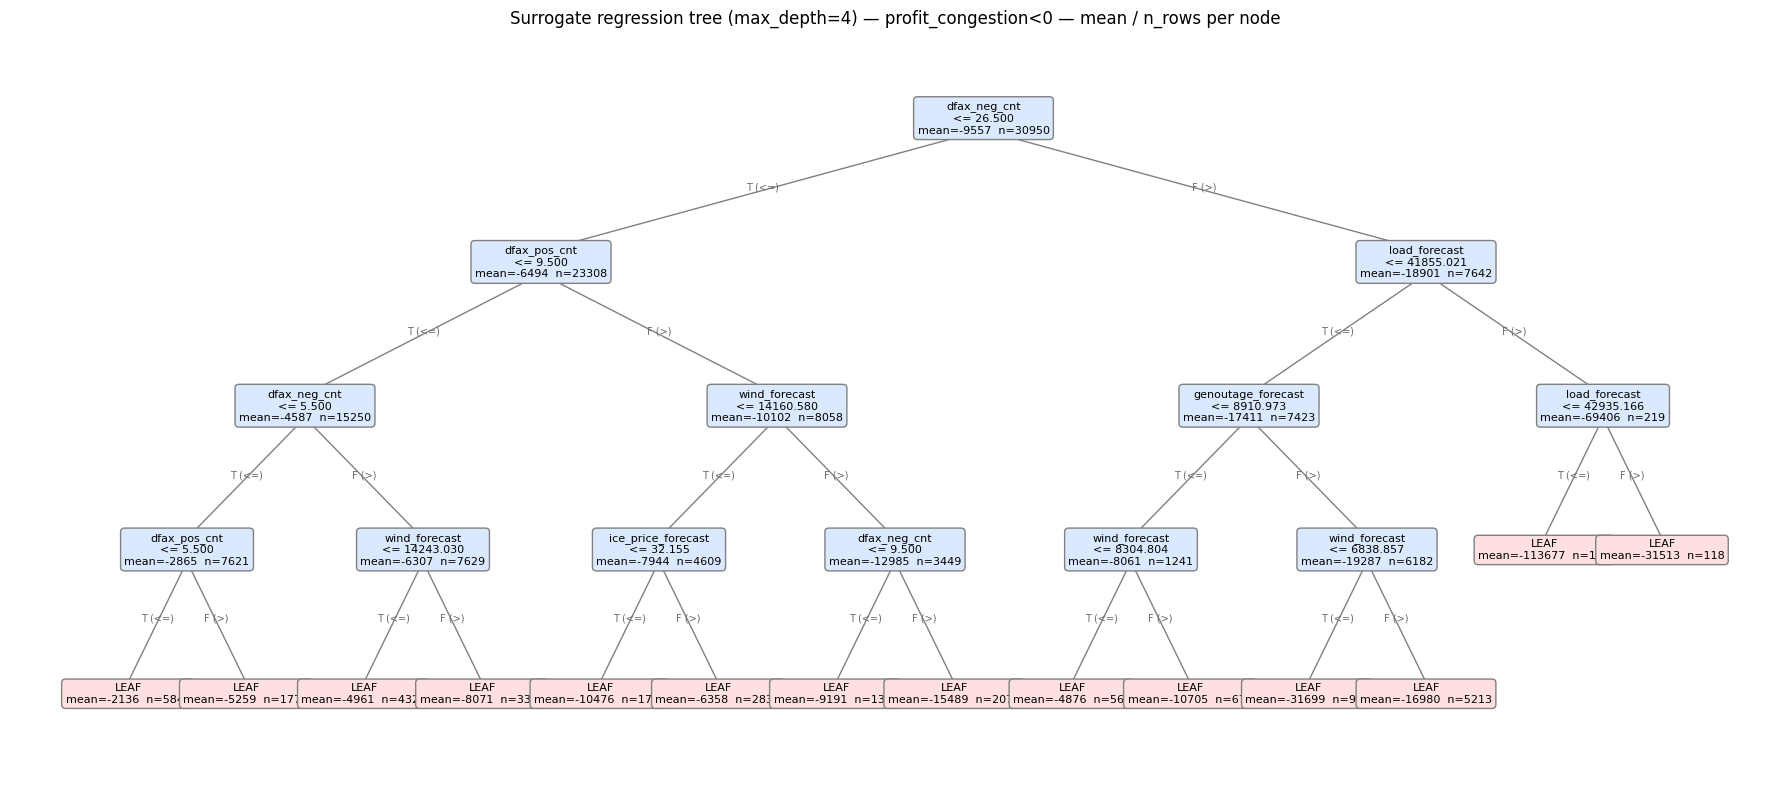

In [ ]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Rerun without the top variables

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.query('profit_congestion < 0').dropna(subset=['profit_congestion']).copy()
y = d['profit_congestion'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in ('dfax_pos_cnt', 'dfax_neg_cnt', 'load_forecast','wind_forecast','genoutage_forecast','ice_price_forecast')]
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=30950  profit_congestion mean=-9557.0  median=-2572.9  p5=-36770.9

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
MaxFlowLimit,0.0718,0.1576,1.0
dfax_max,0.0573,0.1256,2.0
dfax_absmean,0.0520,0.0715,3.0
long_profit_sum_1m,0.0375,0.0513,5.0
dfax_mean,0.0419,0.0443,6.0
dfax_min,0.0356,0.0486,7.0
FlowRatio,0.0432,0.0284,8.0
rt_spike_1y,0.0358,0.0315,9.5
dfax_absmax,0.0316,0.0359,10.0
short_profit_sum_1y,0.0311,0.0386,10.0



=== in-sample fit ===
  LightGBM      R2=0.359  MAE=8551.3
  RandomForest  R2=0.105  MAE=9695.6

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [MaxFlowLimit <= 286.900]  mean=   -9557.0  n_rows=30950
    T> [dfax_max <= 0.745]  mean=   -7711.1  n_rows=22670
      T> [dfax_max <= 0.025]  mean=   -7506.9  n_rows=22366
        T> [dfax_max <= -0.010]  mean=   -4961.4  n_rows= 6441
          T> LEAF  mean=   -3014.5  n_rows= 2168
          F> LEAF  mean=   -5949.1  n_rows= 4273
        F> [dfax_absmean <= 0.062]  mean=   -8536.5  n_rows=15925
          T> LEAF  mean=   -9977.6  n_rows=10355
          F> LEAF  mean=   -5857.5  n_rows= 5570
      F> [rt_nz_cnt_1y <= 105.500]  mean=  -22728.2  n_rows=  304
        T> [dfax_min <= -0.057]  mean=  -15037.7  n_rows=  202
          T> LEAF  mean=  -20234.1  n_rows=  100
          F> LEAF  mean=   -9943.3  n_rows=  102
        F> LEAF  mean=  -37958.3  n_rows=  102
    F> [KV <= 287.500]  mean=  -14611.2  n_rows= 8280
      

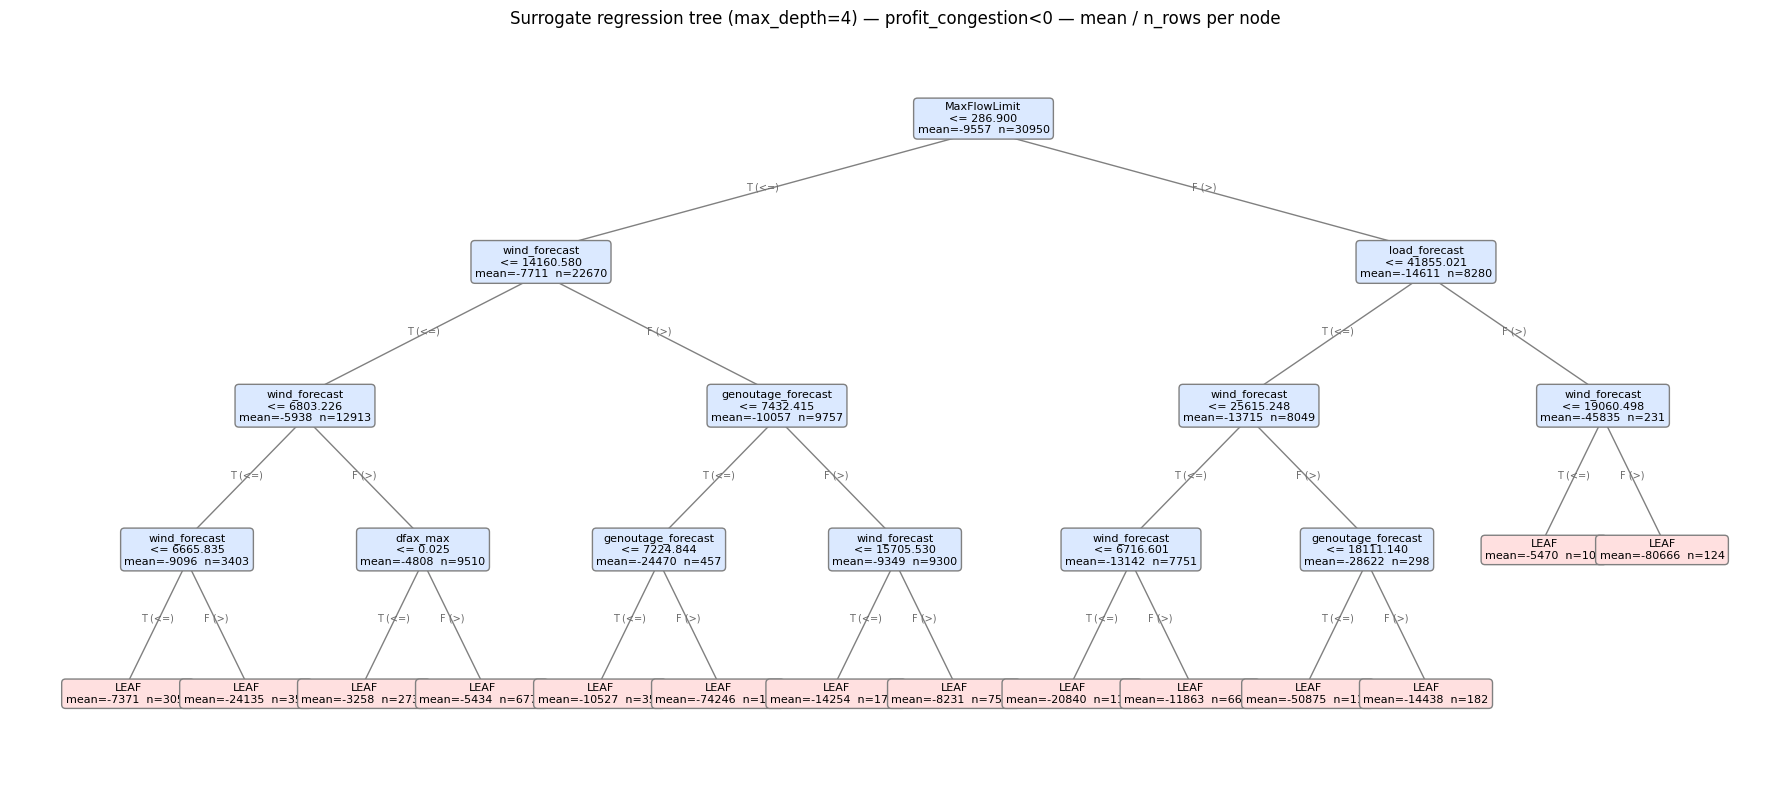

In [ ]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# ---------- out-of-sample check on holdout_df ----------
dh = (holdout_df.query('rtm_sum_1m<-200 and profit_congestion < 0')
      .dropna(subset=['profit_congestion']).copy())
yh = dh['profit_congestion'].astype(float)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

print(f'holdout_df: rows={len(yh)}  profit_congestion mean={yh.mean():.1f}  median={yh.median():.1f}')

def eval_model(name, model, X):
    pred = model.predict(X)
    print(f'\n=== {name} on holdout_df ===')
    print(f'  R2={r2_score(yh, pred):.3f}  MAE={mean_absolute_error(yh, pred):.1f}  '
          f'RMSE={root_mean_squared_error(yh, pred):.1f}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=11307  profit_congestion mean=-8229.2  median=-2461.9

=== LightGBM on holdout_df ===
  R2=-0.151  MAE=9098.5  RMSE=16610.2

=== RandomForest on holdout_df ===
  R2=-0.038  MAE=9119.6  RMSE=15773.8


# Break down by KV and train model separately 

In [ ]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group')]
sev = lambda g: ((g['rt_da'] < -3000) & (g['short_profit'] < -400000) & (g['profit_congestion'] < 0)).astype(int)

def kv_tree(g, grp):
    y = sev(g); Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== KV_group={grp}  rows={len(g)}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,d=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*d}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],d+1,'T>'); show(t.children_right[n],d+1,'F>')
    show()

for grp, g in train_df_filter.groupby('KV_group'):
    if len(g) >= 500 and g['bad_rtda'].sum() >= 30: kv_tree(g, grp)
    else: print(f'\n== KV_group={grp}: too few (rows={len(g)}, pos={int(g.bad_rtda.sum())}) ==')

interested = train_df.query('rt_da < -3000 and short_profit<-400000 and profit_congestion < 0')


== KV_group=02_<=115  rows=29176  pos=12  base=0.04% ==
  top: {'long_profit_sum_1y': 0.48, 'FlowRatio': 0.36, 'short_profit_sum_1m': 0.16}
  [long_profit_sum_1y <= -3566199.38]  pur= 0.0%  n1=12  rec=100.0%
    T>LEAF  pur= 1.8%  n1=3  rec=25.0%
    F>[FlowRatio <= 1.17]  pur= 0.0%  n1=9  rec=75.0%
      T>[short_profit_sum_1m <= -1238948.50]  pur= 0.0%  n1=7  rec=58.3%
        T>LEAF  pur= 1.0%  n1=2  rec=16.7%
        F>LEAF  pur= 0.0%  n1=5  rec=41.7%
      F>LEAF  pur= 0.2%  n1=2  rec=16.7%

== KV_group=03_138  rows=45283  pos=36  base=0.08% ==
  top: {'dfax_absmax': 0.39, 'wind_forecast': 0.31, 'dam_sum_1m': 0.14, 'rtm_lag1': 0.07, 'short_profit_sum_1m': 0.05}
  [dam_sum_1m <= -14818.62]  pur= 0.1%  n1=36  rec=100.0%
    T>[dfax_absmax <= 0.73]  pur= 0.5%  n1=28  rec=77.8%
      T>[rtm_lag1 <= -7329.06]  pur= 0.3%  n1=19  rec=52.8%
        T>LEAF  pur= 1.8%  n1=5  rec=13.9%
        F>LEAF  pur= 0.3%  n1=14  rec=38.9%
      F>[wind_forecast <= 14374.49]  pur= 4.4%  n1=9  rec=25.0

In [ ]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group','rtm_sum_7d')]  # drop split var

def seg_tree(g, name):
    y = g['bad_rtda']; Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== {name}  rows={len(g):,}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,dep=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*dep}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  tot={int(tot)}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],dep+1,'T>'); show(t.children_right[n],dep+1,'F>')
    show()

m = train_df_filter['rtm_sum_7d'] <= -15000
seg_tree(train_df_filter[m],  'rtm_sum_7d <= -15000')
seg_tree(train_df_filter[~m], 'rtm_sum_7d >  -15000')



== rtm_sum_7d <= -15000  rows=3,612  pos=389  base=10.77% ==
  top: {'rtda_1d': 0.37, 'rtda_sum_1y': 0.25, 'wind_forecast': 0.14, 'rtda_avg_3m': 0.09, 'ice_price_forecast': 0.09}
  [rtda_1d <= -2797.83]  pur=10.8%  n1=389  tot=3612  rec=100.0%
    T>[rtda_sum_1y <= -109140.14]  pur=19.8%  n1=162  tot=818  rec=41.6%
      T>[rtda_sum_7d <= -21549.29]  pur=32.6%  n1=71  tot=218  rec=18.3%
        T>LEAF  pur=41.2%  n1=42  tot=102  rec=10.8%
        F>LEAF  pur=25.0%  n1=29  tot=116  rec= 7.5%
      F>[ice_price_forecast <= 74.27]  pur=15.2%  n1=91  tot=600  rec=23.4%
        T>LEAF  pur=12.2%  n1=59  tot=482  rec=15.2%
        F>LEAF  pur=27.1%  n1=32  tot=118  rec= 8.2%
    F>[wind_forecast <= 14518.42]  pur= 8.1%  n1=227  tot=2794  rec=58.4%
      T>[rtda_sum_1y <= -39188.56]  pur= 5.2%  n1=82  tot=1583  rec=21.1%
        T>LEAF  pur= 7.8%  n1=60  tot=765  rec=15.4%
        F>LEAF  pur= 2.7%  n1=22  tot=818  rec= 5.7%
      F>[rtda_avg_3m <= -477.19]  pur=12.0%  n1=145  tot=1211  rec=

# Extreme rt_da tail on full train_df — how good is FlowRatio vs other drivers


In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the extreme LEFT tail (smallest / most negative rt_da) since that's the risk side
TAUS = [0.01, 0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample, full train_df) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.01 model (the most extreme tail)
imp = pd.Series(models[0.01].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===')
display(imp.head(15).round(4).to_frame('gain'))
fr_rank = list(imp.index).index('FlowRatio') + 1 if 'FlowRatio' in imp.index else None
print(f"\nFlowRatio rank: {fr_rank} of {len(imp)}   gain={imp.get('FlowRatio', float('nan')):.4f}")

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=133430  rt_da mean=-58.9  median=0.0  p1=-3656.6  p5=-676.7

=== pinball loss by quantile (in-sample, full train_df) ===
  tau=0.01  pinball_loss=22.17
  tau=0.05  pinball_loss=75.70

=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===


,gain
rtm_lag1,0.0502
wind_forecast,0.0469
FlowRatio,0.0364
rtm_sum_7d,0.0249
ice_price_forecast,0.0214
gas_price_forecast,0.0207
rtm_sum_1m,0.0188
load_forecast,0.0186
rt_spike_3y,0.0182
dfax_std,0.0176



FlowRatio rank: 3 of 85   gain=0.0364

=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.01  target=0.01  actual_coverage=0.007
  tau=0.05  target=0.05  actual_coverage=0.046


In [ ]:
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_pinball_loss

# ---------- how good is FlowRatio alone at the extreme tail? ----------
tail_taus = [0.01, 0.05]

rho_all, p_all = spearmanr(d['FlowRatio'], y)
print(f'Spearman(FlowRatio, rt_da) overall: rho={rho_all:.3f}  p={p_all:.1e}')

for tau in tail_taus:
    thr = y.quantile(tau)
    in_tail = y <= thr
    rho_t, p_t = spearmanr(d.loc[in_tail, 'FlowRatio'], y[in_tail])
    print(f'  within bottom {tau*100:.0f}% (rt_da <= {thr:.1f}, n={int(in_tail.sum())}): '
          f'Spearman(FlowRatio, rt_da) rho={rho_t:.3f}  p={p_t:.1e}')

# single-feature quantile model: FlowRatio ONLY, vs the full multivariate model, at the same taus
Xf = d[['FlowRatio']].copy()
print('\n=== FlowRatio-only vs full-feature quantile model: pinball loss ===')
for tau in tail_taus:
    mf = lgb.LGBMRegressor(objective='quantile', alpha=tau, n_estimators=400, learning_rate=0.05,
                           num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                           random_state=0, n_jobs=-1, verbose=-1).fit(Xf, y)
    pf = mf.predict(Xf)
    loss_flowratio_only = mean_pinball_loss(y, pf, alpha=tau)
    loss_full = scores[tau]
    gain_pct = (loss_flowratio_only - loss_full) / loss_flowratio_only * 100
    print(f'  tau={tau:<5} FlowRatio-only={loss_flowratio_only:.2f}   full-model={loss_full:.2f}   '
          f'gain_from_others={gain_pct:.1f}%')


Spearman(FlowRatio, rt_da) overall: rho=nan  p=nan
  within bottom 1% (rt_da <= -3656.6, n=1335): Spearman(FlowRatio, rt_da) rho=nan  p=nan
  within bottom 5% (rt_da <= -676.7, n=6672): Spearman(FlowRatio, rt_da) rho=nan  p=nan

=== FlowRatio-only vs full-feature quantile model: pinball loss ===
  tau=0.01  FlowRatio-only=60.84   full-model=22.17   gain_from_others=63.6%
  tau=0.05  FlowRatio-only=119.68   full-model=75.70   gain_from_others=36.7%


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da (full train_df) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [rtda_sum_7d <= -40003.303]  mean=     -58.9  n_rows=133430
    T> LEAF  mean=   -2736.4  n_rows=  143
    F> [rtda_sum_7d <= -1070.702]  mean=     -56.0  n_rows=133287
      T> [rtda_sum_3m <= -47656.691]  mean=    -205.5  n_rows=25001
        T> [rt_max_3m <= -15122.946]  mean=    -775.6  n_rows= 1818
          T> LEAF  mean=    -343.8  n_rows=  721
          F> LEAF  mean=   -1059.4  n_rows= 1097
        F> [rtm_sum_7d <= -51504.768]  mean=    -160.8  n_rows=23183
          T> LEAF  mean=    2166.2  n_rows=  100
          F> LEAF  mean=    -170.9  n_rows=23083
      F> [rtda_avg_7d <= 991.860]  mean=     -21.5  n_rows=108286
        T> [rtda_sum_1y <= -71.813]  mean=     -26.9  n_rows=106479
          T> LEAF  mean=     -47.2  n_rows=79597
          F> LEAF  mean=      33.3  n_rows=26882
        F> [rtm_sum_3y <= -1296185.750]  mean=     300.1  n_rows= 1807
          T> LEAF  mean=    -694.3  n_rows=  144
          F> LEAF  me

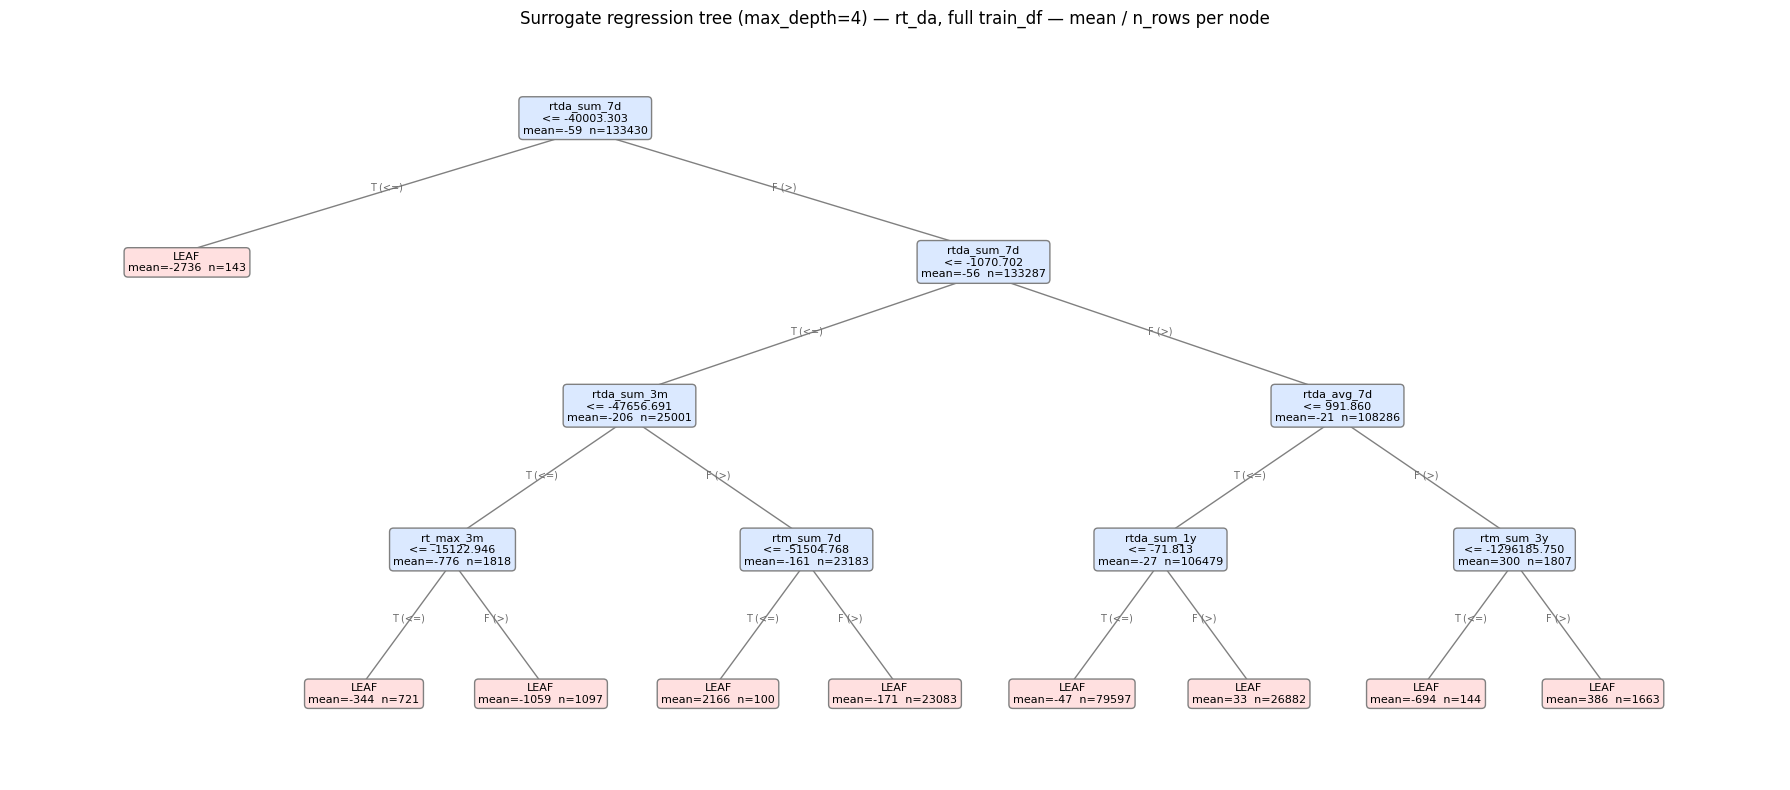

In [ ]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, full train_df — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Design cut and reflect it on the portfolio and calculate the P&L 

In [ ]:
# exposure = pd.read_csv(file_loc + 'exposure_dthr.csv')
# # stream bid_dthr.csv in chunks, keep only short_profit > 0 (avoids loading the whole file)

# Analysis on the big loss day, RTM patterns 

In [ ]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq

sql = 'SELECT * FROM `movetocloud-999.qctest.SPP_bids_table`'
bids = download_df_from_bq(sql, print_flag=True)

Query size 2947.992 MB   Est. Cost @$6.25/TB: $ 0.018
time_taken for downloading df from bq:  0.9  minutes


# Big RTM loss days — RT-spike patterns

**Case studies (worst short-profit days)**

1. **2025-08-06, node 1484** — big RTM in the lag-2-day window; RT stayed elevated for 6+ consecutive hours. We bid 530 MW short and cleared 428.
2. **2023-08-28, node 881** — elevated RTM in the lag-4-day window and across the past month; RTM stayed high for 6+ hours, and we bid **more** during the RTM-binding hours.
3. **2026-01-16, node 1030** — present in the lag-3-day window; RT spiked for two hours, and our bid MW were concentrated in exactly those hours.
4. **2025-07-21, node 1484** — present over the lag-30-day window; RT spiked across multiple hours — the first occurrence in the last two weeks. DA was not high but RT was, and we bid heavily in those hours.
5. **2024-09-27, node 1301** — recurring over the last month; the 27th was the first occurrence in 7 days. DA was quite small (the loss was RT-driven).

## Summary

1. **Every** large short-profit loss shows an **RT spike over multiple hours within the last 30 days** — though the spiking hours are **not necessarily consecutive**.
2. **DA fails to react to the RT spike for more than two weeks**, and that persistent DA-vs-RT disconnect is what turns into the large RT-spike loss.

## Control

- **Cut** when a node shows an **RT spike over multiple (not necessarily consecutive) hours in a single day within the past 30 days**.
- **Cut more aggressively when DA has not been reacting to those spikes over the past 5 days** (persistent DA-vs-RT divergence).


# Shrink bids by constraint-family-day scale factor

Same idea as the SPP scale-table BQ step, done locally on `bids` + `train_df`:
decide a shrink factor per **(dt, constraint_family_num)**, then push it down to the
node-level `bid_mw` through each node's dfax to that family (directional, |dfax|>cutoff,
most-aggressive cut when a node loads several risky families).

In [2]:
import numpy as np, pandas as pd

def scale_bids_by_family(bids, scale_df, dfax_cutoff=0.05,
                         factor_col='final_factor', kv_groups=None):
    """Push a per-(dt, constraint_family_num) shrink factor down to node-level bids.

    bids     : one row per (dt, node_num, incdec, constraint_family_num); bid_mw repeats
               across the families a node loads. Needs columns: dfax, bid_mw.
    scale_df : per (dt, constraint_family_num) with `factor_col` (<=1 shrinks, 1 = keep),
               optionally a KV_group column (only used when kv_groups is passed).
    returns  : one row per (dt, node_num, incdec) with node_factor, bid_mw_original, scaled_bid_mw.
    """
    b = bids.copy(); b['dt'] = b['dt'].astype(str)
    s = scale_df.copy(); s['dt'] = s['dt'].astype(str)
    keep = ['dt', 'constraint_family_num', factor_col] + (['KV_group'] if kv_groups else [])
    b = b.merge(s[keep], on=['dt', 'constraint_family_num'], how='left')

    # a family only shrinks the side its dfax loads:
    #   dfax>0 -> injecting (Increment) raises flow;  dfax<0 -> withdrawing (Decrement) raises flow
    inc_side = (b['incdec'] == 'Increment') & (b['dfax'] > 0)
    dec_side = (b['incdec'] == 'Decrement') & (b['dfax'] < 0)
    eligible = (inc_side | dec_side) & (b['dfax'].abs() > dfax_cutoff) & b[factor_col].notna()
    if kv_groups is not None:
        eligible &= b['KV_group'].isin(kv_groups)
    b['row_factor'] = np.where(eligible, b[factor_col], 1.0)

    # most aggressive cut across every family that loads this node-bid (mirrors MIN() in the BQ step)
    node_factor = (b.groupby(['dt', 'node_num', 'incdec'])['row_factor']
                     .min().rename('node_factor').reset_index())
    # collapse the exploded bids back to one row per (dt, node, incdec)
    node_bids = (b.drop_duplicates(['dt', 'node_num', 'incdec'])
                   [['dt', 'node_num', 'incdec', 'bid_mw']]
                   .merge(node_factor, on=['dt', 'node_num', 'incdec'], how='left'))
    node_bids['node_factor'] = node_bids['node_factor'].fillna(1.0)
    node_bids['bid_mw_original'] = node_bids['bid_mw']
    node_bids['scaled_bid_mw'] = node_bids['bid_mw'] * node_bids['node_factor']
    return node_bids


In [13]:
# ---- how much flow each (dt, constraint_family_num) is loaded with, by side ----
# exposure = MW of flow the bids push onto the constraint = bid_mw * |dfax|
DFAX_CUTOFF = 0.05
_e = bids[bids['dfax'].abs() > DFAX_CUTOFF].copy()
_e = _e[((_e['incdec'] == 'Increment') & (_e['dfax'] > 0)) |
        ((_e['incdec'] == 'Decrement') & (_e['dfax'] < 0))]
_e['flow_mw'] = _e['bid_mw'] * _e['dfax'].abs()   # bid MW -> flow on the constraint
family_day_exposure = (_e.groupby(['dt', 'constraint_family_num'])
                         .agg(family_bid_mw=('bid_mw', 'sum'),
                              family_flow_mw=('flow_mw', 'sum')).reset_index())
print('family-day exposures:', family_day_exposure.shape[0])
display(family_day_exposure.sort_values('family_flow_mw', ascending=False).head())


family-day exposures: 1385892


,dt,constraint_family_num,family_bid_mw,family_flow_mw
200010,2022-02-15,902.0,13480.267235,6628.948426
196898,2022-02-11,902.0,13151.496536,6439.595844
101417,2021-09-26,902.0,16448.450682,5803.766479
195379,2022-02-08,902.0,9833.409222,4765.924727
900150,2024-09-06,902.0,13978.692311,4755.503206


In [14]:
portfolio_df = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')

In [4]:
from nighthawk.util.bigquery_functions import download_df_from_bq
import numpy as np, pandas as pd

b = bids

# family-day totals -> worst 100 by short_profit
fam = b.groupby(['dt','constraint_family_num'], as_index=False).agg(
        fam_short=('short_profit','sum'), fam_long=('long_profit','sum'))
top = fam.nsmallest(100, 'fam_short')
sub = b.merge(top[['dt','constraint_family_num']], on=['dt','constraint_family_num'])

def conc(g):
    gs = g[g['short_profit'] < 0].sort_values('short_profit')   # loss-contributing nodes
    tot = -gs['short_profit'].sum(); s = (-gs['short_profit']/tot) if tot else -gs['short_profit']
    return pd.Series({
        'n_loss_nodes': len(gs),
        'top1_node':  int(gs['node_num'].iloc[0]) if len(gs) else -1,
        'top1_dfax':  gs['dfax'].iloc[0] if len(gs) else np.nan,
        'top1_short_clear_mw': gs['short_clear_mw'].iloc[0] if len(gs) else np.nan,
        'top1_short_profit':   gs['short_profit'].iloc[0] if len(gs) else np.nan,
        'top1_share': s.iloc[0]      if len(gs) else np.nan,
        'top3_share': s.iloc[:3].sum() if len(gs) else np.nan,
        'hhi':        (s**2).sum()     if len(gs) else np.nan,
        'dfax_absmax': g['dfax'].abs().max(),
        'dfax_abs_3rd': (g['dfax'].abs().sort_values(ascending=False).iloc[2]
                         if g['dfax'].notna().sum() >= 3 else np.nan),
    })

summary = (sub.groupby(['dt','constraint_family_num']).apply(conc).reset_index()
              .merge(top, on=['dt','constraint_family_num']).sort_values('fam_short').reset_index(drop=True))

v = int(summary['top1_share'].notna().sum())
print(f"median top-1 node share: {summary['top1_share'].median():.1%}")
print(f"days 1 node >= 50%     : {(summary['top1_share']>=0.5).sum()}/{v}")
print(f"days top-3 >= 90%      : {(summary['top3_share']>=0.9).sum()}/{v}")
print(f"median HHI            : {summary['hhi'].median():.2f}")

summary['regime'] = np.where(summary['top1_share']>=0.5, 'single_node','broadly_coupled')
print(summary.groupby('regime').agg(days=('fam_short','size'), total_loss=('fam_short','sum'),
        med_top1=('top1_share','median'), med_nodes=('n_loss_nodes','median')).round(2))
display(summary.round(3))


median top-1 node share: 62.7%
days 1 node >= 50%     : 60/100
days top-3 >= 90%      : 52/100
median HHI            : 0.45
                 days  total_loss  med_top1  med_nodes
regime                                                
broadly_coupled    40 -2764892.07      0.33       23.0
single_node        60 -4978829.03      0.84        7.0


,dt,constraint_family_num,n_loss_nodes,top1_node,top1_dfax,top1_short_clear_mw,top1_short_profit,top1_share,top3_share,hhi,dfax_absmax,dfax_abs_3rd,fam_short,fam_long,regime
0,2025-08-06,858.0,1.0,1484.0,0.747,320.017,-396830.064,1.000,1.000,1.000,0.747,0.021,-396830.064,9900.128,single_node
1,2024-03-21,904.0,27.0,1301.0,0.815,1009.534,-282789.452,0.776,0.925,0.621,0.862,0.056,-363747.583,21099.432,single_node
2,2024-09-27,904.0,24.0,662.0,0.806,68.591,-87096.313,0.252,0.700,0.201,0.815,0.678,-345683.772,18058.566,broadly_coupled
3,2023-08-28,146.0,40.0,881.0,0.672,160.651,-117542.483,0.542,0.910,0.421,0.672,0.022,-216659.917,12703.880,single_node
4,2023-08-31,1082.0,7.0,8.0,-0.699,225.637,-166939.027,0.997,1.000,0.995,0.699,0.030,-167399.875,6533.123,single_node
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025-09-24,540.0,31.0,45.0,-0.255,156.305,-28650.449,0.730,0.836,0.541,0.255,0.198,-39154.207,5128.462,single_node
96,2025-06-05,1066.0,2.0,349.0,0.729,133.407,-35750.401,0.916,1.000,0.846,0.729,0.026,-39016.819,1201.541,single_node
97,2022-04-07,902.0,18.0,1020.0,-0.116,79.429,-7691.480,0.198,0.570,0.155,0.884,0.884,-38939.001,34532.346,broadly_coupled
98,2021-09-19,904.0,34.0,1295.0,-0.050,14.999,-5227.043,0.135,0.321,0.070,0.862,0.056,-38788.099,18448.881,broadly_coupled


In [29]:
display(len(summary.query('abs(top1_dfax) == dfax_absmax')))
display(summary.query('abs(top1_dfax) == dfax_absmax').top1_dfax.abs().min())
display(summary.query('abs(top1_dfax) == dfax_absmax').top1_short_clear_mw.quantile(0.25))
display(summary.query('abs(top1_dfax) == dfax_absmax').top3_share.quantile(0.25))

display(summary.query('abs(top1_dfax) != dfax_absmax').top1_dfax.abs().min())
display(summary.query('abs(top1_dfax) != dfax_absmax').top1_short_clear_mw.quantile(0.25))
display(summary.query('abs(top1_dfax) != dfax_absmax').top3_share.quantile(0.25))


60

0.1948

np.float64(88.16416199999998)

np.float64(0.8807070937035179)

0.0194

np.float64(28.065974999999955)

np.float64(0.5615078350081771)

In [49]:
train_df_filter.query('rtm_sum_7d >-3000 and ( FlowRatio <1 or FlowRatio != FlowRatio)')

,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,...,dfax_min,dfax_mean,dfax_std,dfax_absmean,dfax_pos_cnt,dfax_neg_cnt,dfax_strong,dfax_range,dfax_absmax,rt_da_smaller_500
0,2023-05-26,590346,11274.76567,10692.34277,33.485800,0.727139,28.527270,0.000000,NaN,NaN,...,-0.04070,-0.028850,0.013683,0.028850,0.0,4.0,0.000000,0.02370,0.04070,0
12,2024-09-12,704807,20749.02285,33921.91375,357.378894,415.985993,78.172844,57.014037,NaN,NaN,...,-0.10412,-0.002627,0.043446,0.038040,50.0,46.0,0.135417,0.19865,0.10412,0
14,2024-02-19,704807,81497.23812,75824.02034,290.144598,394.538700,63.287650,80.953680,NaN,NaN,...,-0.12470,-0.002108,0.052255,0.038037,31.0,53.0,0.214286,0.25390,0.12920,0
15,2024-01-29,704807,15351.27221,14352.34155,323.540384,241.440737,90.233000,67.618450,NaN,NaN,...,-0.07780,-0.019307,0.042044,0.037579,15.0,46.0,0.262295,0.20700,0.12920,0
16,2023-03-09,704807,18704.02914,8736.12027,193.191622,186.635316,36.923900,42.282600,NaN,NaN,...,-0.08220,-0.016885,0.032222,0.029388,14.0,54.0,0.073529,0.19960,0.11740,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400104,2024-09-20,1224350,25086.43136,40018.48173,623.432908,239.339786,33.525999,98.286364,-769.249398,9104.119078,...,-0.04464,0.017664,0.076870,0.053169,29.0,51.0,0.225000,0.33658,0.29194,1
1400480,2023-05-25,1232934,20015.00715,19200.40182,216.513523,141.654940,67.264514,43.054923,-203.391952,785.170579,...,-0.06222,-0.025494,0.034762,0.041740,9.0,32.0,0.170732,0.11016,0.06222,0
1401735,2025-10-02,1366269,-12310.80489,-7046.12254,152.920140,8.513522,27.141604,0.804288,NaN,NaN,...,-0.04430,0.016636,0.024306,0.028041,14.0,3.0,0.000000,0.09230,0.04800,0
1405181,2025-10-05,1785773,-1232.54164,-2055.07827,70.394352,261.083201,4.478890,32.560360,-308.099657,2941.742754,...,-0.02569,0.088384,0.176233,0.115964,3.0,4.0,0.428571,0.47729,0.45160,1


In [58]:
# ---- build the per-family-day shrink factor from train_df (EDIT this rule) ----
# train_df is at (dt, constraint_family_num) level. Set final_factor per family-day:
#   final_factor = 1.0  -> keep bid unchanged
#   final_factor < 1.0  -> shrink that family's node bids to that fraction
scale_df = train_df[['dt', 'constraint_family_num']].drop_duplicates().copy()
scale_df['final_factor'] = 1.0

# ── Design the cut: each rule = (name, condition, MW limit) ───────────────────
# condition is evaluated on the family-day table (train_df features + exposure).
# A family-day satisfying a rule is capped so its flow MW <= that rule's limit.
# If several rules apply, the TIGHTEST cap wins. Edit / add rows freely.
RULES = [
    ('severe_rtm_7d', lambda f: f['rtm_sum_7d'] <= -9622,                             700.0)
    # ('worst_rt_7d',   lambda f: f['rt_max_7d']  <= -3338,                             500.0),
    # ('binding_flow',  lambda f: (f['FlowRatio'] >= 0.95) & (f['rtm_sum_1m'] <= -200), 700.0),
]

# columns your RULES reference — pulled from train_df onto the family-day table
feat_cols = ['rtm_sum_7d', 'rt_max_7d', 'FlowRatio', 'rtm_sum_1m']

fd = family_day_exposure.merge(
        train_df.drop_duplicates(['dt', 'constraint_family_num'])[
            ['dt', 'constraint_family_num'] + feat_cols],
        on=['dt', 'constraint_family_num'], how='left')
fd['dt'] = fd['dt'].astype(str)

# apply rules — each caps flow to its limit; tightest cut wins
fd['final_factor'] = 1.0
fd['applied_rule']  = ''
for name, cond, mw in RULES:
    hit  = cond(fd).fillna(False) & fd['family_flow_mw'].notna()
    cand = np.where(hit & (fd['family_flow_mw'] > mw), mw / fd['family_flow_mw'], 1.0)
    take = cand < fd['final_factor']
    fd.loc[take, 'applied_rule'] = name
    fd['final_factor'] = np.minimum(fd['final_factor'], cand)

scale_df = fd[['dt', 'constraint_family_num', 'final_factor', 'applied_rule']].copy()

print('family-days cut, by rule:')
print(scale_df.loc[scale_df.final_factor < 1, 'applied_rule'].value_counts())
print('\ntightest cuts:')
print(scale_df.sort_values('final_factor').head(10).to_string(index=False))


# ---- apply the factor down to node-level bids ----
scaled_bids = scale_bids_by_family(bids, scale_df, dfax_cutoff=DFAX_CUTOFF)
tot0, tot1 = scaled_bids['bid_mw_original'].sum(), scaled_bids['scaled_bid_mw'].sum()
print('node bids:', scaled_bids.shape[0], '| shrunk:', int((scaled_bids['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.1f}%')
display(scaled_bids[scaled_bids['node_factor'] < 1].head(10))


family-days cut, by rule:
applied_rule
severe_rtm_7d    63
Name: count, dtype: int64

tightest cuts:
        dt  constraint_family_num  final_factor  applied_rule
2025-03-29                  902.0      0.437718 severe_rtm_7d
2024-04-09                  902.0      0.451753 severe_rtm_7d
2024-04-06                  902.0      0.487582 severe_rtm_7d
2024-04-05                  902.0      0.505556 severe_rtm_7d
2025-03-30                  902.0      0.506264 severe_rtm_7d
2025-04-12                  902.0      0.509731 severe_rtm_7d
2024-11-15                  937.0      0.535844 severe_rtm_7d
2023-11-12              1191596.0      0.567013 severe_rtm_7d
2023-11-11              1191596.0      0.578047 severe_rtm_7d
2025-04-26               321546.0      0.578480 severe_rtm_7d
node bids: 200386 | shrunk: 1670
total bid MW  before=31,501,759  after=31,397,673  reduction=0.3%


,dt,node_num,incdec,bid_mw,node_factor,bid_mw_original,scaled_bid_mw
32,2024-10-07,1039.0,Increment,145.269431,0.884277,145.269431,128.458456
157,2024-08-13,1288.0,Decrement,198.850000,0.708115,198.850000,140.808571
307,2024-04-05,1343.0,Decrement,240.980000,0.505556,240.980000,121.828969
578,2025-03-27,339.0,Decrement,425.625000,0.654803,425.625000,278.700468
579,2025-04-25,1569.0,Increment,981.400000,0.837065,981.400000,821.495245
617,2025-04-11,847.0,Decrement,101.100000,0.957612,101.100000,96.814598
718,2022-04-23,410.0,Decrement,522.492501,0.959573,522.492501,501.369454
738,2024-06-17,1083.0,Increment,284.500000,0.673164,284.500000,191.515286
904,2024-11-05,1084.0,Increment,350.000000,0.857013,350.000000,299.954632
1001,2023-11-12,1006.0,Increment,388.250000,0.567013,388.250000,220.142700


In [ ]:
scale_df.query('dt == "2025-03-29" and constraint_family_num  == 902')

,dt,constraint_family_num,family_bid_mw,family_flow_mw
1059085,2025-03-29,902.0,9219.525,1599.201688


In [24]:
# ---- apply node_factor onto the hourly portfolio_df, keyed by (dt, node_num, incdec) ----
nf = scaled_bids[['dt', 'node_num', 'incdec', 'node_factor']].copy()
nf['dt'] = nf['dt'].astype(str); nf['node_num'] = nf['node_num'].astype(int)

portfolio_df['dt'] = portfolio_df['dt'].astype(str)
portfolio_df['node_num'] = portfolio_df['node_num'].astype(int)

portfolio_df = portfolio_df.merge(nf, on=['dt', 'node_num', 'incdec'], how='left')
portfolio_df['node_factor'] = portfolio_df['node_factor'].fillna(1.0)   # untouched bids pass through
portfolio_df['bid_mw_original'] = portfolio_df['bid_mw']
portfolio_df['bid_mw'] = portfolio_df['bid_mw'] * portfolio_df['node_factor']

tot0, tot1 = portfolio_df['bid_mw_original'].sum(), portfolio_df['bid_mw'].sum()
print('portfolio rows:', len(portfolio_df), '| scaled rows:', int((portfolio_df['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.2f}%')
portfolio_df.head()


portfolio rows: 10237060 | scaled rows: 125304
total bid MW  before=31,501,815  after=31,397,728  reduction=0.33%


,dt,strategy,hr,incdec,segment,node_num,bid_mw,bid_price,capacity,node_factor,bid_mw_original
0,2021-06-02,Darwin,1,Increment,11.0,30,1.8,21.856845,medium,1.0,1.8
1,2021-06-02,Darwin,1,Increment,10.0,172,1.8,15.583938,medium,1.0,1.8
2,2021-06-02,Darwin,1,Increment,11.0,172,1.8,18.105542,medium,1.0,1.8
3,2021-06-02,Darwin,1,Increment,11.0,269,1.8,18.700198,low,1.0,1.8
4,2021-06-02,Darwin,1,Decrement,7.0,293,1.8,20.551130,low,1.0,1.8


In [27]:
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

In [ ]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
import gc
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df[bid_mw_col] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * (df['bid_price'] > df[da_total_col]),
                              df[bid_mw_col] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df[bid_mw_col] * df['bid_ref_price']),
                                       abs(df[bid_mw_col] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * df['bid_ref_price'],
                                       df[bid_mw_col] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table_new  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw')
profit_table_old  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw_original')


del ref_df            # merged into profit_table; not used afterward
gc.collect()

2483

In [43]:
def portfolio_summary(df, label=None, profit_col='profit', cong_col='profit_congestion',
                      bid_col='bid_mw', clear_col='clear_mw', date_col='dt', q=0.05):
    """One-line portfolio summary computed directly from the table's own columns."""
    daily = df.groupby(date_col)[profit_col].sum()          # daily P&L
    var_thr = daily.quantile(q)                             # 5% VaR = 5th-pctile daily P&L
    out = {
        'total_profit':            df[profit_col].sum(),
        'total_profit_congestion': df[cong_col].sum(),
        'worst_day_loss':          daily.min(),
        f'VaR{int(q*100)}_daily':  var_thr,                 # loss you exceed 5% of days
        f'CVaR{int(q*100)}_daily': daily[daily <= var_thr].mean(),  # mean of the worst 5% of days
        'bid_mw_sum':              df[bid_col].sum(),
        'clear_mw_sum':            df[clear_col].sum(),
        'n_days':                  int(daily.shape[0]),
    }
    return pd.Series(out, name=label)

new = portfolio_summary(profit_table_new, 'new')
old = portfolio_summary(profit_table_old, 'old', bid_col='bid_mw_original')

cmp = pd.concat([old, new], axis=1)
cmp['abs_change']   = cmp['new'] - cmp['old']
cmp['rel_change_%'] = (cmp['abs_change'] / cmp['old'].abs() * 100).round(2)   # vs old, sign-preserving
display(cmp)



,old,new,abs_change,rel_change_%
total_profit,4.804034e+07,4.787577e+07,-164573.226730,-0.34
total_profit_congestion,5.393654e+07,5.374421e+07,-192331.266110,-0.36
worst_day_loss,-4.036390e+05,-4.036390e+05,0.000000,0.00
VaR5_daily,-3.354812e+04,-3.354812e+04,0.000000,0.00
CVaR5_daily,-8.011458e+04,-7.962258e+04,491.992681,0.61
bid_mw_sum,3.150176e+07,3.139767e+07,-104086.842790,-0.33
clear_mw_sum,7.175326e+06,7.153936e+06,-21389.600000,-0.30
n_days,1.770000e+03,1.770000e+03,0.000000,0.00


In [50]:
train_df.columns

Index(['constraint_family_num', 'dt', 'profit', 'profit_congestion',
       'long_profit', 'short_profit', 'FlowRatio', 'ShadowPrice_min',
       'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam', 'rtm',
       'rt_da', 'rt_binds', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d',
       'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y',
       'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d',
       'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m',
       'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m',
       'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y',
       'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y',
       'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m',
       'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m',
       'rt_max_3m', 'rt_max_1y', 'rt_max_3y', 'rt_nz_cnt_7d', 'rt_nz_cnt_1m',
       'rt_nz_cnt_3m', 'rt_nz_cnt_1y', 'rt_nz_cnt_3y', 'rt_spike_7

In [25]:
from nighthawk.util.sql_functions import download_df_from_sql_db

q = """
SELECT dt,
       incdec, 
       SUM(ABS(bid_mw * bid_price)) AS bid_notional
FROM odessa_Bid.SPPFinalBidsBeforeAnyCut
WHERE dt >= DATE_SUB(CURDATE(), INTERVAL 2 MONTH)
GROUP BY dt, incdec
ORDER BY dt, incdec
"""
spp_bid_notional = download_df_from_sql_db(q)
print(spp_bid_notional.shape)
spp_bid_notional.head()


(126, 3)


,dt,incdec,bid_notional
0,2026-05-17,Decrement,268644.600
1,2026-05-17,Increment,159969.706
2,2026-05-18,Decrement,276983.676
3,2026-05-18,Increment,146609.950
4,2026-05-19,Decrement,296778.231


In [12]:
from nighthawk.util.sql_functions import download_df_from_sql_db
from nighthawk.data.network.node import Node

# --- 1) bid aggregates per (dt, incdec), past two months (heavy work stays in SQL) ---
bids = download_df_from_sql_db("""
    SELECT dt,
           incdec,
           SUM(ABS(bid_mw * bid_price)) AS bid_notional,    -- your first metric
           SUM(bid_mw * bid_price)      AS bid_mw_price,     -- signed, for the slack spread
           SUM(bid_mw)                  AS bid_mw_total
    FROM odessa_Bid.SPPFinalBidsBeforeAnyCut
    WHERE dt >= DATE_SUB(CURDATE(), INTERVAL 2 MONTH)
    GROUP BY dt, incdec
""")
bids['dt'] = bids['dt'].astype(str)

# --- 2) daily DA slack at SPP hub (node 636), averaged over the 24 hours ---
SPP_HUB = 636
slack_hr = Node(node_nums=[SPP_HUB], market='SPP').get_price(
    bids['dt'].min(), bids['dt'].max(), component=['Slack'], type=['DA'])   # -> dt, hr, node_num, da_slack
slack_daily = (slack_hr.assign(dt=lambda d: d['dt'].astype(str))
                       .groupby('dt', as_index=False)['da_slack'].mean()
                       .rename(columns={'da_slack': 'slack'}))

# --- 3) merge slack per date, compute sum(bid_mw*(bid_price - slack)) ---
spp_bid_summary = bids.merge(slack_daily, on='dt', how='left')
spp_bid_summary['bid_mw_slack_spread'] = (
    spp_bid_summary['bid_mw_price'] - spp_bid_summary['slack'] * spp_bid_summary['bid_mw_total'])

spp_bid_summary = spp_bid_summary[['dt', 'incdec', 'slack',
                                   'bid_notional', 'bid_mw_slack_spread']].sort_values(['dt', 'incdec'])
print(spp_bid_summary.shape)
spp_bid_summary.head()


(126, 5)


,dt,incdec,slack,bid_notional,bid_mw_slack_spread
0,2026-05-17,Decrement,10.227196,268644.600,79467.997962
1,2026-05-17,Increment,10.227196,159969.706,-67207.370797
2,2026-05-18,Decrement,20.473225,276983.676,-4833.821206
3,2026-05-18,Increment,20.473225,146609.950,7218.659617
4,2026-05-19,Decrement,20.500299,296778.231,-40164.243704


In [24]:
import pandas as pd

target_dt = '2026-07-18'
prev_dt   = (pd.Timestamp(target_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')  # 2026-07-17

# carry previous day's hourly slack onto July 18 (hour-for-hour)
carry = slack_hr.loc[slack_hr['dt'] == prev_dt, ['hr', 'slack']].assign(dt=target_dt)
assert not carry.empty, f"no slack for {prev_dt} to carry forward"
slack_hr = pd.concat([slack_hr[slack_hr['dt'] != target_dt], carry], ignore_index=True)

# re-merge (drop prior slack cols to avoid slack_x/slack_y) and recompute
bids = (bids.drop(columns=['slack', 'slack_spread', 'notional'], errors='ignore')
            .merge(slack_hr, on=['dt', 'hr'], how='left'))

slack_by_incdec = (
    bids.assign(slack_spread=bids['bid_mw'] * (bids['bid_price'] - bids['slack']))
        .groupby(['dt', 'incdec'], as_index=False)['slack_spread'].sum())

slack_spread_wide = (
    slack_by_incdec.pivot(index='dt', columns='incdec', values='slack_spread')
        .rename(columns={'Increment': 'inc_slack_spread', 'Decrement': 'dec_slack_spread'})
        .reset_index())
slack_spread_wide.tail()


incdec,dt,dec_slack_spread,inc_slack_spread
58,2026-07-14,35340.832319,32510.286017
59,2026-07-15,12497.701875,78641.223244
60,2026-07-16,-41536.380523,162175.864021
61,2026-07-17,41112.801075,187848.262911
62,2026-07-18,-2397.411360,104688.646214


In [31]:
# --- 2b) fill the bid day (2026-07-18) with the previous day's daily slack ---
import pandas as pd
target_dt = '2026-07-18'
prev_dt   = (pd.Timestamp(target_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')  # 2026-07-17

prev_val = slack_daily.loc[slack_daily['dt'] == prev_dt, 'slack']
assert not prev_val.empty, f"no slack for {prev_dt} to carry forward"

slack_daily = pd.concat(
    [slack_daily[slack_daily['dt'] != target_dt],
     pd.DataFrame({'dt': [target_dt], 'slack': [prev_val.iloc[0]]})],
    ignore_index=True)


# Shrink the bids by the Optimization

In [16]:
b = bids   # dt, constraint_family_num, node_num, dfax

# --- one day ---
def day_dfax_matrix(dt):
    d = b[b['dt'] == dt]
    return d.pivot_table(index='constraint_family_num', columns='node_num',
                         values='dfax', aggfunc='first')
matrices = {dt: g.pivot_table(index='constraint_family_num', columns='node_num',
                              values='dfax', aggfunc='first')
            for dt, g in b.groupby('dt')}      # the matrix for that day
pos_matrices = {dt: M.where(M > 0, 0.0) for dt, M in matrices.items()}   # keep +dfax, else 0
neg_matrices = {dt: M.where(M < 0, 0.0) for dt, M in matrices.items()}   # keep -dfax, else 0

             # rows = constraints, cols = nodes, cells = dfax (NaN where no coupling)

In [17]:
g = portfolio_df.groupby(['dt', 'node_num', 'incdec'], as_index=False)['bid_mw'].sum()
wide = (g.pivot_table(index=['dt', 'node_num'], columns='incdec',
                      values='bid_mw', fill_value=0)
          .rename_axis(columns=None)     # drop the 'incdec' name off the columns axis
          .reset_index())


In [ ]:
train_df_filter.rtm_hr_max

In [ ]:
import numpy as np, pandas as pd

RULES = [
    (lambda d: d['rtm_sum_7d'] < -3000,
     lambda d: np.where(111000 / -((d['rt_max_7d'] + d['rtm_sum_7d']/np.maximum(d['rt_nz_cnt_7d'],1))/2 - d['dam_lag1']) < 0, 50,
               np.minimum(111000 / -((d['rt_max_7d'] + d['rtm_sum_7d']/np.maximum(d['rt_nz_cnt_7d'],1))/2 - d['dam_lag1']), 50))),
    (lambda d: d['FlowRatio'] > 1,
     lambda d: np.where(111000 / -((d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/2 - d['dam_lag1']) < 0, 50,
               np.minimum(111000 / -((d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/2 - d['dam_lag1']), 50))),
    (lambda d: d['rtm_sum_3m'] < -3000,
     lambda d: np.where(111000 / -((d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/2 - d['dam_lag1']) < 0, 50,
               np.minimum(111000 / -((d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/2 - d['dam_lag1']), 50))),
]


def assign_family_limit(df, rules):
    limit = pd.Series(np.inf, index=df.index)
    for cond, limfn in rules:
        lv = pd.Series(limfn(df), index=df.index)
        limit = limit.mask(cond(df), np.minimum(limit, lv))   # matched rows take the tighter limit
    return limit

train_df_filter['limit'] = assign_family_limit(train_df_filter, RULES)


In [36]:
import numpy as np, pandas as pd
from scipy.optimize import linprog

USE_ABS_NEG = True   # see note below: makes decrement cuts actually reduce exposure
portfolio_df = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
# limit per (dt, constraint_family_num) from train_df_filter
limit_by_key = train_df_filter.set_index(['dt','constraint_family_num'])['limit']

rows = []
dates = sorted(pos_matrices)               # or a subset while testing: sorted(pos_matrices)[:20]
for dt in dates:
    P = pos_matrices[dt].fillna(0)                                   # constraints x nodes  (+dfax)
    N = neg_matrices[dt].reindex(index=P.index, columns=P.columns).fillna(0)   # (-dfax)
    nodes, cons = list(P.columns), list(P.index)
    n = len(nodes)
    if n == 0: continue

    # bid vectors for this date, aligned to the matrix's node columns
    w = wide[wide['dt'] == dt].set_index('node_num')
    inc = w['Increment'].reindex(nodes).fillna(0).to_numpy(float)
    dec = w['Decrement'].reindex(nodes).fillna(0).to_numpy(float)

    Pm = P.to_numpy(float)
    Nc = (-N.to_numpy(float)) if USE_ABS_NEG else N.to_numpy(float)   # dec contribution
    flow0 = Pm @ inc + Nc @ dec                                      # current flow per constraint

    lim  = np.array([limit_by_key.get((dt, c), np.inf) for c in cons], float)
    keep = np.isfinite(lim)                                          # only constraints with a limit

    # variables x = [ch1 (inc cuts), ch2 (dec cuts)];  min sum(ch1)+sum(ch2)
    # P@(inc-ch1) + Nc@(dec-ch2) <= lim   ->   -Pm@ch1 - Nc@ch2 <= lim - flow0
    A_ub = np.hstack([-Pm[keep], -Nc[keep]])
    b_ub = lim[keep] - flow0[keep]
    bounds = [(0, inc[i]) for i in range(n)] + [(0, dec[i]) for i in range(n)]

    res = linprog(np.ones(2*n), A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    ch1, ch2 = (res.x[:n], res.x[n:]) if res.success else (inc.copy(), dec.copy())  # infeasible -> zero out

    inc_pct = np.divide(ch1, inc, out=np.zeros_like(ch1), where=inc > 0)   # fraction of inc cut
    dec_pct = np.divide(ch2, dec, out=np.zeros_like(ch2), where=dec > 0)
    for i, nd in enumerate(nodes):
        rows.append({'dt': dt, 'node_num': nd,
                     'inc_change_pct': inc_pct[i], 'dec_change_pct': dec_pct[i],
                     'inc_mult': 1 - inc_pct[i],   'dec_mult': 1 - dec_pct[i]})

mult_df = pd.DataFrame(rows)

# --- 4) store the multiplier back on portfolio_df (incdec-specific) ---
portfolio_df = portfolio_df.merge(mult_df[['dt','node_num','inc_mult','dec_mult']],
                                  on=['dt','node_num'], how='left')
portfolio_df['node_mult'] = np.where(portfolio_df['incdec'].eq('Increment'),
                                     portfolio_df['inc_mult'].fillna(1.0),
                                     portfolio_df['dec_mult'].fillna(1.0))
portfolio_df['bid_mw_cut'] = portfolio_df['bid_mw'] * portfolio_df['node_mult']


In [41]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
import gc
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df[bid_mw_col] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * (df['bid_price'] > df[da_total_col]),
                              df[bid_mw_col] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df[bid_mw_col] * df['bid_ref_price']),
                                       abs(df[bid_mw_col] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * df['bid_ref_price'],
                                       df[bid_mw_col] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table_new  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw_cut')
profit_table_old  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw')


del ref_df            # merged into profit_table; not used afterward
gc.collect()

0

In [42]:
def portfolio_summary(df, label=None, profit_col='profit', cong_col='profit_congestion',
                      bid_col='bid_mw', clear_col='clear_mw', date_col='dt', q=0.05):
    """One-line portfolio summary computed directly from the table's own columns."""
    daily = df.groupby(date_col)[profit_col].sum()          # daily P&L
    var_thr = daily.quantile(q)                             # 5% VaR = 5th-pctile daily P&L
    out = {
        'total_profit':            df[profit_col].sum(),
        'total_profit_congestion': df[cong_col].sum(),
        'worst_day_loss':          daily.min(),
        f'VaR{int(q*100)}_daily':  var_thr,                 # loss you exceed 5% of days
        f'CVaR{int(q*100)}_daily': daily[daily <= var_thr].mean(),  # mean of the worst 5% of days
        'bid_mw_sum':              df[bid_col].sum(),
        'clear_mw_sum':            df[clear_col].sum(),
        'n_days':                  int(daily.shape[0]),
    }
    return pd.Series(out, name=label)

new = portfolio_summary(profit_table_new, 'new', bid_col='bid_mw_cut')
old = portfolio_summary(profit_table_old, 'old', bid_col='bid_mw')

cmp = pd.concat([old, new], axis=1)
cmp['abs_change']   = cmp['new'] - cmp['old']
cmp['rel_change_%'] = (cmp['abs_change'] / cmp['old'].abs() * 100).round(2)   # vs old, sign-preserving
display(cmp)



,old,new,abs_change,rel_change_%
total_profit,4.804034e+07,4.414897e+07,-3.891371e+06,-8.10
total_profit_congestion,5.393654e+07,4.966581e+07,-4.270734e+06,-7.92
worst_day_loss,-4.036390e+05,-1.883250e+05,2.153141e+05,53.34
VaR5_daily,-3.354812e+04,-2.777508e+04,5.773045e+03,17.21
CVaR5_daily,-8.011458e+04,-6.232465e+04,1.778992e+04,22.21
bid_mw_sum,3.150176e+07,2.843522e+07,-3.066539e+06,-9.73
clear_mw_sum,7.175326e+06,6.456058e+06,-7.192678e+05,-10.02
n_days,1.770000e+03,1.770000e+03,0.000000e+00,0.00


# Hourly Level Cut 

In [1]:
import numpy as np, pandas as pd

RULES = [
    (lambda d: d['rtm_sum_7d'] < -3000,
     lambda d: np.where(111000 / -((d['rtm_lag1']+ d['rt_max_7d'] + d['rtm_sum_7d']/np.maximum(d['rt_nz_cnt_7d'],1))/3 - d['dam_lag1']) < 0, 30,
               np.minimum(111000 / -((d['rtm_lag1']+d['rt_max_7d'] + d['rtm_sum_7d']/np.maximum(d['rt_nz_cnt_7d'],1))/3 - d['dam_lag1']), 30))),
    (lambda d: d['FlowRatio'] > 1,
     lambda d: np.where(111000 / -((d['rtm_lag1']+d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/3 - d['dam_lag1']) < 0, 30,
               np.minimum(111000 / -((d['rtm_lag1']+d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/3 - d['dam_lag1']), 30))),
    (lambda d: d['rtm_sum_3m'] < -3000,
     lambda d: np.where(111000 / -((d['rtm_lag1']+d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/3 - d['dam_lag1']) < 0, 50,
               np.minimum(111000 / -((d['rtm_lag1']+d['rt_max_3m'] + d['rtm_sum_3m']/np.maximum(d['rt_nz_cnt_3m'],1))/3 - d['dam_lag1']), 50))),
]

# RULES = [
#     # 1) recent 7d RT stress — move = mean(rtm_hr_max lag2,7d) - mean(dam_hr_max lag2,7d)
#     (lambda d: d['rtm_sum_7d'] < -3000,
#      lambda d: np.where(
#          20000 / ((d['rtm_hr_max_lag2'] + d['rtm_hr_max_7d'])/2 - (d['dam_hr_max_lag2'] + d['dam_hr_max_7d'])/2) < 0,
#          30,
#          np.minimum(20000 / ((d['rtm_hr_max_lag2'] + d['rtm_hr_max_7d'])/2 - (d['dam_hr_max_lag2'] + d['dam_hr_max_7d'])/2), 30))),

#     # 2) flow-ratio breach — same move as rule 1
#     (lambda d: d['FlowRatio'] > 1,
#      lambda d: np.where(
#          20000 / ((d['rtm_hr_max_lag2'] + d['rtm_hr_max_7d'])/2 - (d['dam_hr_max_lag2'] + d['dam_hr_max_7d'])/2) < 0,
#          30,
#          np.minimum(20000 / ((d['rtm_hr_max_lag2'] + d['rtm_hr_max_7d'])/2 - (d['dam_hr_max_lag2'] + d['dam_hr_max_7d'])/2), 30))),

#     # 3) 3-month RT stress — move = rtm_hr_max_3m - dam_hr_max_3m
#     (lambda d: d['rtm_sum_3m'] < -3000,
#      lambda d: np.where(
#          20000 / (d['rtm_hr_max_3m'] - d['dam_hr_max_3m']) < 0,
#          50,
#          np.minimum(20000 / (d['rtm_hr_max_3m'] - d['dam_hr_max_3m']), 50))),
# ]

def assign_family_limit(df, rules):
    limit = pd.Series(np.inf, index=df.index)
    for cond, limfn in rules:
        lv = pd.Series(limfn(df), index=df.index)
        limit = limit.mask(cond(df), np.minimum(limit, lv))   # matched rows take the tighter limit
    return limit

train_df_filter['limit'] = assign_family_limit(train_df_filter, RULES)


NameError: name 'train_df_filter' is not defined

In [126]:
train_df_filter.sort_values(['short_profit']).head(30)[['rt_da','constraint_family_num','dt','monitored_name','short_profit','limit','rtm_hr_max_lag2','rtm_hr_max_7d','rtm_hr_max_3m']]

,rt_da,constraint_family_num,dt,monitored_name,short_profit,limit,rtm_hr_max_lag2,rtm_hr_max_7d,rtm_hr_max_3m
680456,-20646.6958,858.0,2025-08-06,lnweav-tallgras,-388243.405645,17.439743,0.0000,0.0000,1488.7058
87976,-4978.9293,904.0,2024-09-27,multi-elementconstraint.spsnmties.spsnmties,-345683.771557,30.000000,0.0000,1064.6091,1454.0494
295998,-15041.1202,146.0,2023-08-28,lnchar_ck-watford,-216659.917321,19.795539,3.6975,1499.9800,1499.9800
450025,-5277.4237,1082.0,2023-08-31,xfmrturk_pp-turk_pp,-167399.874988,30.000000,0.0000,777.3332,777.3332
1334374,-14163.9702,904.0,2024-06-19,multi-elementconstraint.spsnmties.spsnmties,-160068.635807,20.781532,167.0998,283.9735,1466.8280
371128,-11341.7274,937.0,2024-09-17,xfmrcimarron-cimarron,-144456.856241,50.000000,285.8668,285.8668,2606.6010
1333823,-4910.9960,858.0,2025-07-03,lnweav-tallgras,-136811.761646,17.149031,0.0000,1453.5905,1488.6768
532875,-4437.3239,904.0,2024-10-15,multi-elementconstraint.spsnmties.spsnmties,-134924.559715,33.804117,0.0000,0.0000,1475.6790
749461,-18236.5258,1039619.0,2026-01-16,lnsibly161-orrick9,-133557.035737,30.000000,0.0000,1154.3925,1154.3925
741507,-5234.2250,937.0,2024-11-04,xfmrcimarron-cimarron,-128544.223214,30.000000,692.9694,1458.5765,2691.9019


In [95]:
bids.query('dt == "2023-08-31" and constraint_family_num == 1082')

,constraint_family_num,dt,node_num,dfax,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,short_bid_nondfax
185054,1082.0,2023-08-31,903.0,-0.0125,503.93894,-71.60531,1.552500,0.862563,0.00000,0.27875,0.000000,0.000000,69.005
203949,1082.0,2023-08-31,947.0,-0.0118,6516.24805,10956.92552,8.991482,0.053100,2.45558,0.00000,984.639362,0.000000,4.500
178529,1082.0,2023-08-31,887.0,-0.0123,39.93520,654.72422,5.190108,0.221400,0.46002,0.00000,0.262058,0.000000,18.000
222516,1082.0,2023-08-31,1004.0,-0.0119,-940.18343,389.31481,4.029994,2.412071,0.15113,0.80801,192.116745,0.000000,202.695
215480,1082.0,2023-08-31,988.0,-0.0123,0.00000,0.00000,2.041000,3.080227,0.00000,0.00000,0.000000,0.000000,250.425
285690,1082.0,2023-08-31,1219.0,-0.0108,0.00000,0.00000,5.808294,0.063180,0.00000,0.00000,0.000000,0.000000,5.850
197053,1082.0,2023-08-31,942.0,-0.0106,56.37161,139.92525,2.824105,0.289327,0.23744,0.06466,0.000000,-27.836960,27.295
322608,1082.0,2023-08-31,1384.0,0.0176,15089.74888,11581.99918,8.170712,0.724240,3.37744,0.00000,1152.688317,0.000000,41.150
209414,1082.0,2023-08-31,970.0,-0.0119,11919.55040,9948.24544,1.456560,4.996631,0.00000,1.78976,0.000000,-0.338048,419.885
7452,1082.0,2023-08-31,61.0,0.0111,5631.83700,3010.74259,3.937003,1.541346,1.41636,0.28416,614.443381,0.000000,138.860


In [96]:
portfolio_df.query('dt == "2023-08-31" and node_num == 8.0 and incdec == "Decrement"').groupby(['hr','incdec']).sum().reset_index()[['bid_mw']]

,bid_mw
0,9.75
1,13.00
2,13.00
3,16.12
4,13.00
5,13.00
6,16.25
7,3.25
8,9.75
9,26.00


In [ ]:
# Hourly level cut 
import numpy as np, pandas as pd
from scipy.optimize import linprog

portfolio_df = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
portfolio_df['dt'] = portfolio_df['dt'].astype(str)

# hourly limit per (dt, constraint_family_num) — the rules now define the PER-HOUR cap
limit_by_key = train_df_filter.set_index(['dt','constraint_family_num'])['limit']

# hourly bids: one row per (dt, hr, node_num) with Increment / Decrement totals
wide_hr = (portfolio_df.groupby(['dt','hr','node_num','incdec'], as_index=False)['bid_mw'].sum()
             .pivot_table(index=['dt','hr','node_num'], columns='incdec',
                          values='bid_mw', aggfunc='sum', fill_value=0)
             .rename_axis(columns=None).reset_index())
wide_hr['dt'] = wide_hr['dt'].astype(str)

rows = []
for dt in sorted(pos_matrices):
    P = pos_matrices[dt].fillna(0)                                    # dfax>0  (constant across hours)
    N = neg_matrices[dt].reindex(index=P.index, columns=P.columns).fillna(0)
    nodes, cons = list(P.columns), list(P.index)
    n = len(nodes)
    if n == 0: continue
    Pm = P.to_numpy(float)
    Nc = -N.to_numpy(float)                                           # |neg|  -> SHORT exposure only
    lim  = np.array([limit_by_key.get((dt, c), np.inf) for c in cons], float)
    keep = np.isfinite(lim)
    if not keep.any(): continue                                       # no capped constraint that day
    A_ub = np.hstack([-Pm[keep], -Nc[keep]])                          # same every hour (dfax intraday-constant)

    for hr, g in wide_hr[wide_hr['dt'] == dt].groupby('hr'):
        gi  = g.set_index('node_num')
        inc = gi['Increment'].reindex(nodes).fillna(0).to_numpy(float)   # short only via Pm (inc @ dfax>0)
        dec = gi['Decrement'].reindex(nodes).fillna(0).to_numpy(float)   # short only via Nc (dec @ dfax<0)
        if inc.sum() + dec.sum() == 0: continue

        flow0 = Pm @ inc + Nc @ dec                                   # short flow this hour, per constraint
        b_ub  = lim[keep] - flow0[keep]
        if (b_ub >= 0).all(): continue                               # already under every hourly limit -> no cut

        bounds = [(0, inc[i]) for i in range(n)] + [(0, dec[i]) for i in range(n)]
        res = linprog(np.ones(2*n), A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
        ch1, ch2 = (res.x[:n], res.x[n:]) if res.success else (inc.copy(), dec.copy())

        inc_pct = np.divide(ch1, inc, out=np.zeros_like(ch1), where=inc > 0)
        dec_pct = np.divide(ch2, dec, out=np.zeros_like(ch2), where=dec > 0)
        for i, nd in enumerate(nodes):
            if inc_pct[i] > 0 or dec_pct[i] > 0:                      # store only nodes actually cut (sparse)
                rows.append({'dt': dt, 'hr': hr, 'node_num': nd,
                             'inc_mult': 1 - inc_pct[i], 'dec_mult': 1 - dec_pct[i]})

mult_hr = pd.DataFrame(rows)

# --- store the HOURLY multiplier back on portfolio_df ---
portfolio_df = portfolio_df.merge(mult_hr, on=['dt','hr','node_num'], how='left')
portfolio_df['node_mult'] = np.where(portfolio_df['incdec'].eq('Increment'),
                                     portfolio_df['inc_mult'].fillna(1.0),
                                     portfolio_df['dec_mult'].fillna(1.0))
portfolio_df['bid_mw_cut'] = portfolio_df['bid_mw'] * portfolio_df['node_mult']


: 

In [ ]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
import gc
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df[bid_mw_col] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * (df['bid_price'] > df[da_total_col]),
                              df[bid_mw_col] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df[bid_mw_col] * df['bid_ref_price']),
                                       abs(df[bid_mw_col] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * df['bid_ref_price'],
                                       df[bid_mw_col] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table_new  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw_cut')
# profit_table_old  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw')


del ref_df            # merged into profit_table; not used afterward
gc.collect()

In [ ]:
def portfolio_summary(df, label=None, profit_col='profit', cong_col='profit_congestion',
                      bid_col='bid_mw', clear_col='clear_mw', date_col='dt', q=0.1):
    """One-line portfolio summary computed directly from the table's own columns."""
    daily = df.groupby(date_col)[profit_col].sum()          # daily P&L
    var_thr = daily.quantile(q)                             # 5% VaR = 5th-pctile daily P&L
    out = {
        'total_profit':            df[profit_col].sum(),
        'total_profit_congestion': df[cong_col].sum(),
        'worst_day_loss':          daily.min(),
        f'VaR{int(q*100)}_daily':  var_thr,                 # loss you exceed 5% of days
        f'CVaR{int(q*100)}_daily': daily[daily <= var_thr].mean(),  # mean of the worst 5% of days
        'bid_mw_sum':              df[bid_col].sum(),
        'clear_mw_sum':            df[clear_col].sum(),
        'n_days':                  int(daily.shape[0]),
    }
    return pd.Series(out, name=label)

new = portfolio_summary(profit_table_new, 'new', bid_col='bid_mw_cut')
old = portfolio_summary(profit_table_old, 'old', bid_col='bid_mw')

cmp = pd.concat([old, new], axis=1)
cmp['abs_change']   = cmp['new'] - cmp['old']
cmp['rel_change_%'] = (cmp['abs_change'] / cmp['old'].abs() * 100).round(2)   # vs old, sign-preserving
display(cmp)



,old,new,abs_change,rel_change_%
total_profit,4.804034e+07,4.181036e+07,-6.229980e+06,-12.97
total_profit_congestion,5.393654e+07,4.672087e+07,-7.215671e+06,-13.38
worst_day_loss,-4.036390e+05,-2.290590e+05,1.745801e+05,43.25
VaR10_daily,-1.568972e+04,-1.355165e+04,2.138067e+03,13.63
CVaR10_daily,-5.155746e+04,-4.318373e+04,8.373731e+03,16.24
bid_mw_sum,3.150176e+07,2.645211e+07,-5.049652e+06,-16.03
clear_mw_sum,7.175326e+06,5.985716e+06,-1.189609e+06,-16.58
n_days,1.770000e+03,1.770000e+03,0.000000e+00,0.00


In [76]:
import numpy as np, pandas as pd
print("="*64, "\nALIGNMENT / DTYPE CHECK\n" + "="*64)

dt0 = sorted(pos_matrices)[0]; P = pos_matrices[dt0]

print("\n[1] join-key dtypes")
print(f"  pos_matrices : dt={type(dt0).__name__:8} index(cfn)={P.index.dtype}  cols(node)={P.columns.dtype}")
print(f"  train_df     : dt={train_df_filter['dt'].dtype}  cfn={train_df_filter['constraint_family_num'].dtype}  has_limit={'limit' in train_df_filter}")
print(f"  portfolio_df : dt={portfolio_df['dt'].dtype}  node_num={portfolio_df['node_num'].dtype}")
print(f"  wide         : dt={wide['dt'].dtype}  node_num={wide['node_num'].dtype}  cols={list(wide.columns)}")

print("\n[2] limit lookup (the #1 silent-failure point)")
lim_key = train_df_filter.set_index(['dt','constraint_family_num'])['limit']
dup = train_df_filter.duplicated(['dt','constraint_family_num']).any()
print(f"  unique per (dt,cfn): {'PASS' if not dup else 'FAIL — duplicates -> .get returns a Series'}")
fin = [np.isfinite([lim_key.get((dt, c), np.nan) for c in pos_matrices[dt].index]).mean()
       for dt in sorted(pos_matrices)]
print(f"  avg %% constraints with a FINITE limit/day: {np.mean(fin):.1%}")
print(f"  one-day sample lookup: {lim_key.get((dt0, P.index[0]), 'MISS')!r}   (a number = keys match; MISS/nan/inf = mismatch)")
print(f"  NaN limits in train_df_filter: {int(train_df_filter['limit'].isna().sum())}  (silently dropped)")

print("\n[3] bids")
print(f"  negative Increment/Decrement in wide: {'FAIL' if (wide[['Increment','Decrement']]<0).any().any() else 'PASS (all >=0)'}")

print("\n[4] node overlap (one day)")
nm, nw = set(P.columns), set(wide.loc[wide['dt']==dt0,'node_num'])
print(f"  matrix nodes={len(nm)}  wide nodes={len(nw)}  overlap={len(nm & nw)}  (low overlap = dt/node dtype or coverage mismatch)")

print("\n[5] post-merge (only meaningful after you've run the loop + merge)")
if 'node_mult' in portfolio_df.columns:
    print(f"  node_mult NaN (merge miss): {int(portfolio_df['node_mult'].isna().sum())}  (want 0)")
    print(f"  rows actually cut (<1)   : {int((portfolio_df['node_mult']<1).sum())}  (want > 0)")
else:
    print("  node_mult not present yet — run the loop/merge first, then re-run this cell")
print("="*64)


ALIGNMENT / DTYPE CHECK

[1] join-key dtypes
  pos_matrices : dt=str      index(cfn)=float64  cols(node)=float64
  train_df     : dt=object  cfn=int64  has_limit=True
  portfolio_df : dt=object  node_num=int64
  wide         : dt=object  node_num=int64  cols=['dt', 'node_num', 'Decrement', 'Increment']

[2] limit lookup (the #1 silent-failure point)
  unique per (dt,cfn): PASS
  avg %% constraints with a FINITE limit/day: 4.8%
  one-day sample lookup: 'MISS'   (a number = keys match; MISS/nan/inf = mismatch)
  NaN limits in train_df_filter: 0  (silently dropped)

[3] bids
  negative Increment/Decrement in wide: PASS (all >=0)

[4] node overlap (one day)
  matrix nodes=137  wide nodes=137  overlap=137  (low overlap = dt/node dtype or coverage mismatch)

[5] post-merge (only meaningful after you've run the loop + merge)
  node_mult NaN (merge miss): 0  (want 0)
  rows actually cut (<1)   : 6233199  (want > 0)
